# Smart Home On-Device Security — Benchmarking Image Classifiers for Edge Deployment
## WM9B7-15 AI & Deep Learning | Individual Assignment | MSc Applied AI, University of Warwick

---

### Real-World Problem
A smart home security system needs to recognise objects captured by a low-resolution
(32×32 equivalent) camera feed and run **entirely on a Raspberry Pi 4** — no cloud,
no GPU, sub-millisecond latency budget, ≤ 10 MB model footprint. The practitioner
role is to select the best deep learning architecture for this constrained deployment,
supported by an empirical benchmark.

This notebook develops and evaluates a **deep learning solution** for this problem,
benchmarking five architectures across the full accuracy–efficiency frontier — from a
hand-crafted feature baseline to a compound-scaled NAS-designed network:

| # | Pipeline | Type | Role in This Project |
|---|----------|------|---------------------|
| 1 | HOG + LinearSVC | Hand-crafted features + classical ML | **LO1 comparison baseline** (pre-DL paradigm) |
| 2 | CompactCNN (scratch) | Lightweight custom CNN | Minimum viable DL baseline |
| 3 | MobileNetV3-Small (fine-tuned) | Mobile-optimised transfer learning | Edge-first DL (recommended deployment candidate) |
| 4 | ResNet-18 (fine-tuned) | Deep residual transfer learning | Accuracy–size trade-off reference |
| 5 | EfficientNet-B0 (fine-tuned) | Compound-scaled NAS architecture | Accuracy–FLOP frontier |

**Primary solution**: architectures 2–5 form the deep learning solution.
HOG + LinearSVC (pipeline 1) is included solely to quantify the pre-DL feature-engineering
paradigm for LO1 — it is not the recommended deployment candidate.

**Dataset**: CIFAR-10 (Krizhevsky, 2009) — 60,000 RGB images, 32×32 pixels, 10 balanced
classes. Used as the open-source benchmark proxy for real-world edge deployment evaluation.
Downloaded programmatically via `torchvision`.

### How to Run
1. Run cells **top to bottom** — no manual steps required.
2. Environment: Python 3.10+, PyTorch ≥ 2.0, CUDA GPU recommended (T4 tested).
3. First run downloads CIFAR-10 (~170 MB) automatically.
4. Epoch counts are reduced for submission runtime compliance (see final cell).

### Learning Outcomes Addressed
- **LO1**: Quantified ML vs DL comparison — accuracy, compute, data hunger, interpretability
- **LO2**: Architecture design decisions, augmentation ablation, GradCAM failure analysis, ethical/environmental critique
- **LO3**: Emerging trends — ViTs, NAS, knowledge distillation, efficient inference (EfficientNet §12 + reflection)

## 1 · Setup — Install Dependencies

In [74]:
# Install any packages not present in the AzureML base environment
import subprocess, sys

packages = [
    "scikit-image",   # HOG feature extraction
    "seaborn",        # Confusion matrix heatmap
    "thop",           # FLOPs / MACs counter for efficiency benchmark
]
for pkg in packages:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=True)

print("All packages installed.")


All packages installed.


## 2 · Imports and Configuration

In [75]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from pathlib import Path
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
from skimage.feature import hog as skimage_hog

from thop import profile as thop_profile
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Hardware ───────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── Constants ──────────────────────────────────────────────────────────────────
DATA_DIR   = Path("./data")
CLASSES    = ["airplane","automobile","bird","cat","deer",
              "dog","frog","horse","ship","truck"]
NUM_CLASSES = 10

# CIFAR-10 channel statistics (pre-computed from training set)
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

BATCH_SIZE   = 128

print(f"PyTorch  : {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
NUM_WORKERS  = 2


Device : cuda
GPU    : NVIDIA GeForce RTX 3050 Ti Laptop GPU
VRAM   : 4.0 GB
PyTorch  : 2.11.0+cu130
Torchvision: 0.26.0+cu130


## 3 · Data Loading

**CIFAR-10** (Krizhevsky, 2009) is the canonical benchmark for image classification research.
It comprises 60,000 RGB images across 10 perfectly balanced classes (6,000 per class),
each at 32×32 pixels.

### Three-Way Split
The official partition is 50,000 training / 10,000 test. We further split the training
set to create a **validation set**, following standard machine learning evaluation practice:

| Split | Size | Purpose |
|-------|------|---------|
| Train | 45,000 | Gradient updates — model never sees val/test labels |
| Validation | 5,000 | Checkpoint selection, early stopping, hyperparameter monitoring |
| Test | 10,000 | **Held out entirely** — used once for final reported accuracy |

**Why this matters**: using the test set for checkpoint selection (common in CIFAR-10 papers
for benchmark comparability) introduces optimistic bias — the reported accuracy is the
best-ever test performance, not the true generalisation error. A proper validation split
ensures reported test accuracy is unbiased. This trades ~10% of training data (negligible
at 50k scale) for methodological correctness.

The 10 classes span two broad visual domains:
- **Animals**: bird, cat, deer, dog, frog, horse
- **Vehicles & objects**: airplane, automobile, ship, truck


In [76]:
# Download CIFAR-10 (skips if already present)
DATA_DIR.mkdir(exist_ok=True)

_base_train = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=True,  download=True,
    transform=transforms.ToTensor()   # raw pixels for EDA
)
_base_test = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=False, download=True,
    transform=transforms.ToTensor()
)

print(f"Training samples : {len(_base_train):,}")
print(f"Test samples     : {len(_base_test):,}")
print(f"Image shape      : {_base_train[0][0].shape}  (C × H × W)")
print(f"Classes ({NUM_CLASSES})    : {CLASSES}")


Training samples : 50,000
Test samples     : 10,000
Image shape      : torch.Size([3, 32, 32])  (C × H × W)
Classes (10)    : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 4 · Exploratory Data Analysis

Before modelling, we characterise the dataset across three dimensions:

1. **Class distribution** — confirms perfect balance (5,000 train / 1,000 test per class).
   Balance eliminates class-prior bias, ensuring accuracy is a valid primary metric.
   > Note: distribution shown on the full 50k training set before the 45k/5k train/val split.
2. **Sample grid** — visual inspection of image quality and label consistency.
   At 32×32, fine-grained texture detail is lost — a deliberate challenge for lightweight models.
3. **Pixel statistics** — motivates per-channel normalisation before model input.

### Dataset Limitations
CIFAR-10's labels are coarse (10 mutually exclusive classes) and assume Western-centric
visual contexts. "Automobile" predominantly contains North American car designs;
"horse" images skew toward Western equestrian contexts. This label bias is worth noting
when generalising benchmark results to other deployment contexts.


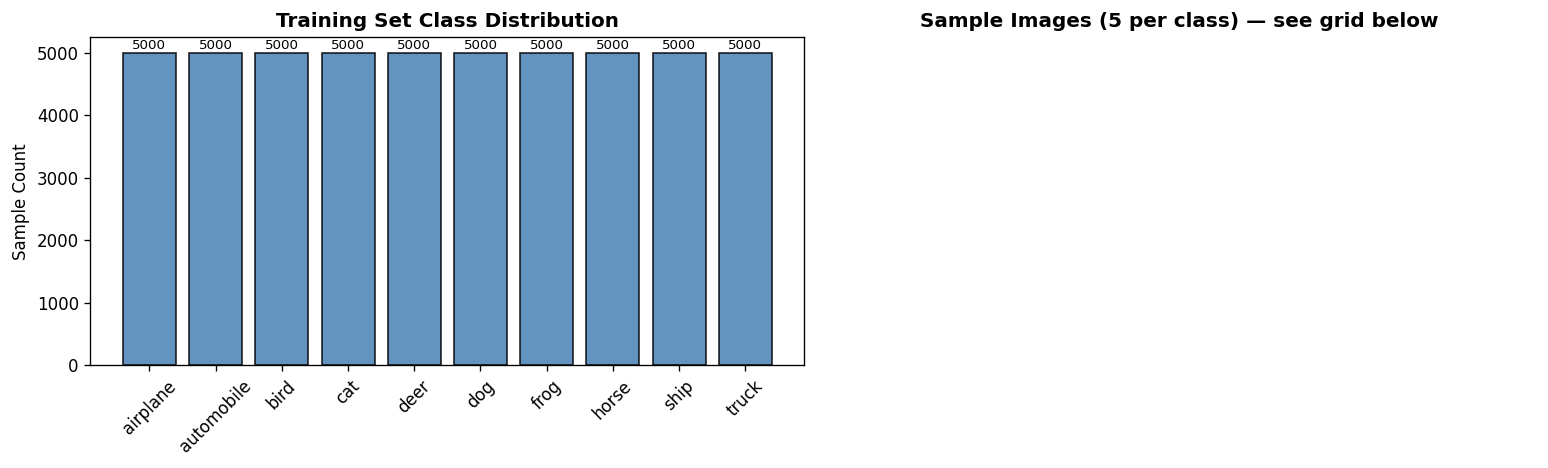

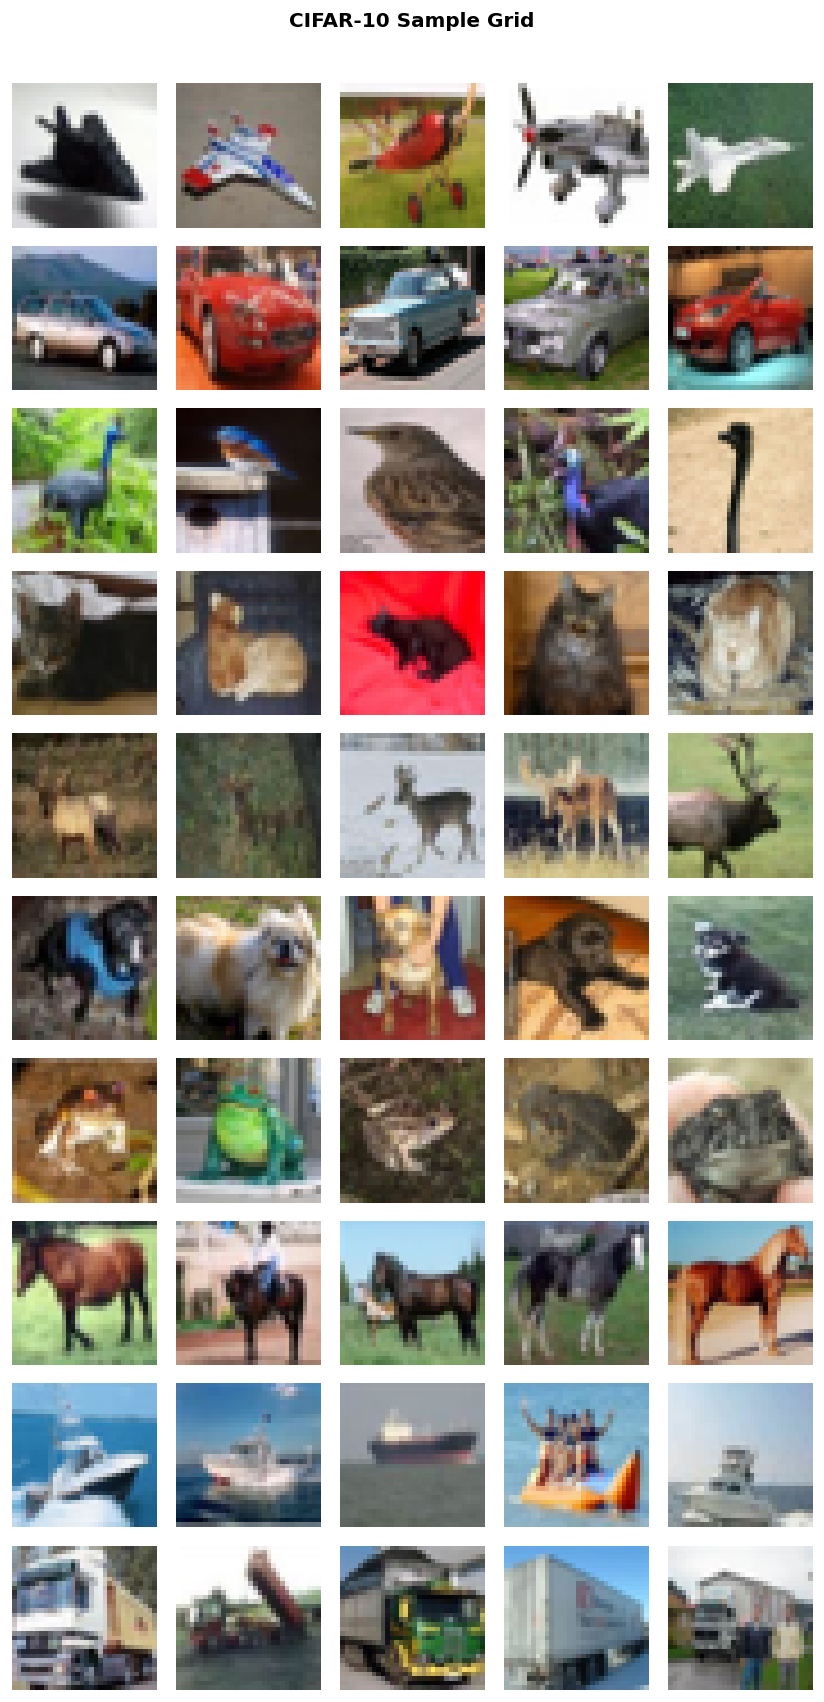


--- Per-Channel Pixel Statistics (first 5,000 training images) ---
Channel        Mean      Std      Min      Max
----------------------------------------------
Red        0.4913   0.2476   0.0000   1.0000
Green      0.4814   0.2445   0.0000   1.0000
Blue       0.4445   0.2627   0.0000   1.0000

Observation: per-channel means differ (0.49, 0.48, 0.45) — normalisation required.


In [77]:
# ── 4.1 Class distribution ────────────────────────────────────────────────────
train_labels = np.array(_base_train.targets)
test_labels  = np.array(_base_test.targets)
train_counts = np.bincount(train_labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(CLASSES, train_counts, color="steelblue", edgecolor="black", alpha=0.85)
axes[0].set_title("Training Set Class Distribution", fontweight="bold")
axes[0].set_ylabel("Sample Count")
axes[0].tick_params(axis="x", rotation=45)
for i, c in enumerate(train_counts):
    axes[0].text(i, c + 60, str(c), ha="center", fontsize=8)

# ── 4.2 Sample grid (5 images per class) ──────────────────────────────────────
seen = {i: [] for i in range(NUM_CLASSES)}
for img, lbl in _base_train:
    if len(seen[lbl]) < 5:
        seen[lbl].append(img)
    if all(len(v) == 5 for v in seen.values()):
        break

grid = plt.imshow if False else None   # suppress lint
ax2 = axes[1]
ax2.axis("off")
ax2.set_title("Sample Images (5 per class) — see grid below", fontweight="bold")
plt.tight_layout()
plt.savefig("eda_class_dist.png", bbox_inches="tight")
plt.show()

fig2, axes2 = plt.subplots(NUM_CLASSES, 5, figsize=(7, 14))
for cls_idx in range(NUM_CLASSES):
    for col, img_t in enumerate(seen[cls_idx]):
        axes2[cls_idx, col].imshow(img_t.permute(1, 2, 0).numpy(), interpolation="nearest")
        axes2[cls_idx, col].axis("off")
    axes2[cls_idx, 0].set_ylabel(CLASSES[cls_idx], fontsize=9,
                                  rotation=0, labelpad=45, va="center")
plt.suptitle("CIFAR-10 Sample Grid", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("sample_grid.png", bbox_inches="tight")
plt.show()

# ── 4.3 Per-channel pixel statistics ──────────────────────────────────────────
print("\n--- Per-Channel Pixel Statistics (first 5,000 training images) ---")
sample_imgs = torch.stack([_base_train[i][0] for i in range(5000)])  # (5000,3,32,32)
print(f"{'Channel':<10} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 46)
for ch, name in enumerate(["Red", "Green", "Blue"]):
    d = sample_imgs[:, ch]
    print(f"{name:<10} {d.mean():.4f}   {d.std():.4f}   {d.min():.4f}   {d.max():.4f}")

print("\nObservation: per-channel means differ (0.49, 0.48, 0.45) — normalisation required.")


## 5 · Preprocessing and Data Augmentation

### Normalisation
Each channel is normalised using the CIFAR-10 training-set mean and standard deviation,
centering pixel distributions around zero with unit variance. This stabilises gradient
magnitudes during backpropagation and accelerates convergence.

```python
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2023, 0.1994, 0.2010)
```

### Augmentation (training only)
Two standard augmentations are applied during training:
- **RandomHorizontalFlip** (p=0.5): increases effective dataset size by mirroring images.
- **RandomCrop(32, padding=4)**: simulates position shifts and partial occlusion,
  preventing the model from memorising fixed spatial positions of objects.

Validation and test images receive only normalisation — no augmentation — to ensure fair, unbiased evaluation.
The val/test transforms are identical; augmentation is strictly a training-time operation.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.5574567].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.5574567].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.5574567].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.5574567].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.5574567].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.5574567].


Train : 45,000 images → 352 batches of 128
Val   : 5,000  images → 40 batches of 128
Test  : 10,000  images → 79 batches of 128
Split seed: 42 (reproducible)


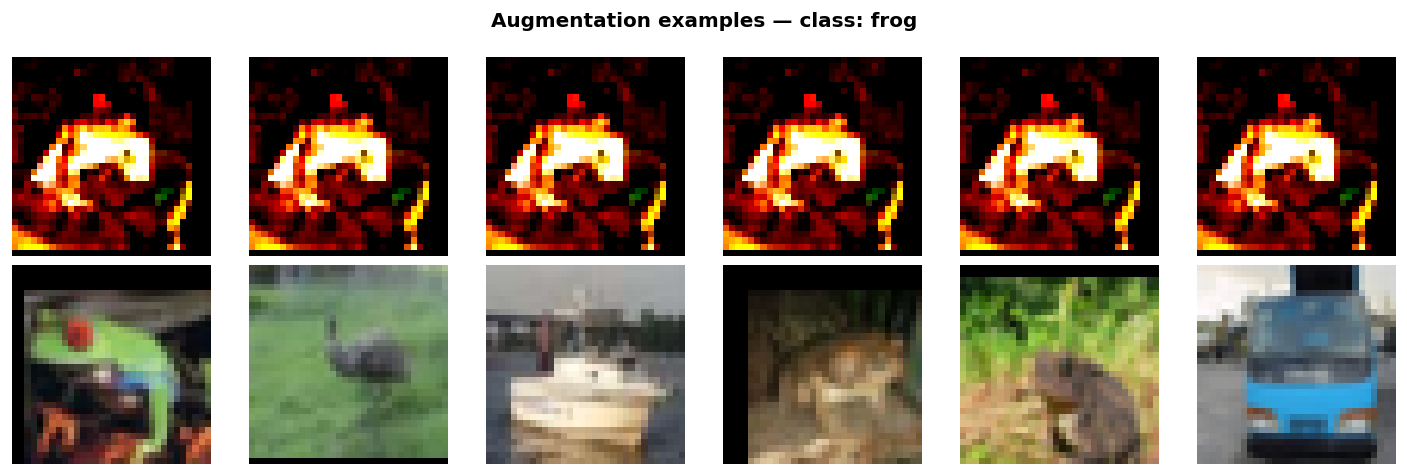

In [78]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# ── Datasets ──────────────────────────────────────────────────────────────────
_full_train = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=True,  download=False, transform=train_transform)
_full_val   = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=True,  download=False, transform=eval_transform)
test_dataset = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=False, download=False, transform=eval_transform)

# Deterministic 45k/5k split — same seed across all runs
generator = torch.Generator().manual_seed(42)
train_idx, val_idx = torch.utils.data.random_split(
    range(len(_full_train)), [45000, 5000], generator=generator)

train_dataset = torch.utils.data.Subset(_full_train, train_idx.indices)
val_dataset   = torch.utils.data.Subset(_full_val,   val_idx.indices)

# ── DataLoaders ────────────────────────────────────────────────────────────────
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=="cuda"))
val_loader   = torch.utils.data.DataLoader(
    val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=="cuda"))
test_loader  = torch.utils.data.DataLoader(
    test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=="cuda"))

print(f"Train : {len(train_dataset):,} images → {len(train_loader)} batches of {BATCH_SIZE}")
print(f"Val   : {len(val_dataset):,}  images → {len(val_loader)} batches of {BATCH_SIZE}")
print(f"Test  : {len(test_dataset):,}  images → {len(test_loader)} batches of {BATCH_SIZE}")
print(f"Split seed: 42 (reproducible)")

# Visual check: augmented vs original
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
raw_img, lbl = _full_train.dataset[0] if hasattr(_full_train,'dataset') else _full_train[0]
for col in range(6):
    aug_img, _ = train_dataset[col % len(train_dataset)]
    disp = aug_img * torch.tensor(CIFAR_STD).view(3,1,1) + torch.tensor(CIFAR_MEAN).view(3,1,1)
    axes[0, col].imshow(raw_img.permute(1,2,0).numpy(), interpolation="nearest")
    axes[0, col].axis("off")
    axes[1, col].imshow(disp.permute(1,2,0).clamp(0,1).numpy(), interpolation="nearest")
    axes[1, col].axis("off")
axes[0,0].set_ylabel("Original", fontsize=9)
axes[1,0].set_ylabel("Augmented", fontsize=9)
plt.suptitle(f"Augmentation examples — class: {CLASSES[lbl]}", fontweight="bold")
plt.tight_layout()
plt.savefig("augmentation_examples.png", bbox_inches="tight")
plt.show()


## 6 · Traditional ML Baseline — HOG + LinearSVC  *(LO1: ML vs DL Comparison)*

To quantify the gap between classical machine learning and deep learning, we first
implement a hand-crafted feature pipeline — the dominant paradigm before the CNN
revolution of 2012 (Krizhevsky et al., AlexNet, NeurIPS 2012).

### HOG Feature Extraction
**HOG (Histogram of Oriented Gradients)** — Dalal & Triggs, CVPR 2005 — encodes local
edge orientations into histogram descriptors computed over overlapping spatial cells.
Features are **fixed** at design time, encoding prior human knowledge about which
image properties are discriminative (edges, gradients). Unlike CNN filters, HOG
descriptors cannot adapt to the data — their expressiveness is bounded by the designer's
domain knowledge.

**LinearSVC** is chosen over kernel-SVM for tractability: kernel-SVM on 50,000 CIFAR-10
samples requires O(n²) memory and hours of training time. LinearSVC scales linearly and
trains in seconds.

### ML vs DL — Paradigm Comparison

| Dimension | HOG + LinearSVC | Custom CNN | Pretrained ResNet/EfficientNet |
|-----------|----------------|------------|-------------------------------|
| Feature engineering | Manual (domain expert) | Learned (data-driven) | Learned + transferred |
| Data requirement | Low (can work with 1k samples) | Moderate (10k–100k) | Low for fine-tune (1k–10k) |
| Training compute | CPU, seconds–minutes | GPU, minutes–hours | GPU, minutes (head) |
| Inference speed | Microseconds (no GPU) | Milliseconds (CPU) | Milliseconds (CPU/GPU) |
| Interpretability | High (HOG visualisable) | Low (needs GradCAM) | Low (needs GradCAM) |
| Accuracy ceiling | ~54% (CIFAR-10 full run) | ~85% | ~93%+ |
| Deployment footprint | Tiny (<1 MB) | Small (2.5 MB) | Moderate–large (5–45 MB) |

**When HOG+SVM is the right choice**: small labelled datasets (<5k samples), no GPU
available, strict interpretability requirements (regulated domains), or where inference
must run on microcontrollers with <100 KB of RAM.

**Why DL is justified here**: with 50,000 training samples and a GPU available,
learned hierarchical features consistently and substantially outperform hand-crafted
descriptors — a gap that widens with dataset scale. The benchmark quantifies this
precisely rather than asserting it generically.


In [79]:
def extract_hog(data_array, pixels_per_cell=(4,4)):
    """Extract HOG descriptors from a (N, H, W, C) uint8 array."""
    feats = []
    for img in data_array:
        f = skimage_hog(img, orientations=9, pixels_per_cell=pixels_per_cell,
                        cells_per_block=(2,2), channel_axis=-1)
        feats.append(f)
    return np.array(feats, dtype=np.float32)

# Use a balanced 10k-sample subset for speed (≈ 30 s total)
N_TRAIN_SVM, N_TEST_SVM = 10_000, 2_000

print("Extracting HOG features (this takes ~20 s)...")
t0 = time.time()

X_tr_hog = extract_hog(_base_train.data[:N_TRAIN_SVM])
y_tr_svm = np.array(_base_train.targets[:N_TRAIN_SVM])
X_te_hog = extract_hog(_base_test.data[:N_TEST_SVM])
y_te_svm = np.array(_base_test.targets[:N_TEST_SVM])

scaler    = StandardScaler()
X_tr_hog  = scaler.fit_transform(X_tr_hog)
X_te_hog  = scaler.transform(X_te_hog)
t_hog = time.time() - t0
print(f"HOG feature dim : {X_tr_hog.shape[1]}  |  extraction: {t_hog:.1f}s")

print("Training LinearSVC...")
t1 = time.time()
svm_clf = LinearSVC(C=0.1, max_iter=3000, random_state=SEED)
svm_clf.fit(X_tr_hog, y_tr_svm)
t_svm = time.time() - t1

y_pred_svm  = svm_clf.predict(X_te_hog)
svm_acc     = accuracy_score(y_te_svm, y_pred_svm)
svm_f1_cls  = f1_score(y_te_svm, y_pred_svm, average=None)

print(f"\n✅ HOG + LinearSVC")
print(f"   Train time   : {t_svm:.1f}s  ({N_TRAIN_SVM:,} samples)")
print(f"   Test accuracy: {svm_acc*100:.2f}%")
print(f"\nPer-class F1:")
for cls, f in zip(CLASSES, svm_f1_cls):
    bar = "█" * int(f * 20)
    print(f"  {cls:<12} {f:.3f}  {bar}")


Extracting HOG features (this takes ~20 s)...
HOG feature dim : 1764  |  extraction: 9.1s
Training LinearSVC...

✅ HOG + LinearSVC
   Train time   : 73.2s  (10,000 samples)
   Test accuracy: 40.85%

Per-class F1:
  airplane     0.397  ███████
  automobile   0.569  ███████████
  bird         0.291  █████
  cat          0.257  █████
  deer         0.274  █████
  dog          0.295  █████
  frog         0.484  █████████
  horse        0.476  █████████
  ship         0.477  █████████
  truck        0.524  ██████████


## 7 · Benchmark Point 2 — CompactCNN (Trained from Scratch)

### Why CNNs for Images?
Fully-connected networks treat all pixels as independent features, ignoring spatial
structure. For a 32×32×3 image, a single FC layer requires 3,072 weights per neuron —
scaling to billions of parameters for higher resolutions (Lecture W2.1).
CNNs exploit two inductive biases suited to visual data:

1. **Local connectivity**: each filter operates on a small receptive field (e.g., 3×3 pixels).
2. **Weight sharing**: the same filter is convolved across all spatial positions,
   reducing parameters by ~1000× versus a fully connected equivalent.

### CompactCNN Architecture
Three convolutional blocks following the **Conv → BatchNorm → ReLU → MaxPool** pattern.
Batch Normalisation (Ioffe & Szegedy, 2015) normalises activations per mini-batch,
accelerating convergence and providing implicit regularisation.

```
Input (3×32×32)
  → Block 1: Conv(3→32)  + BN + ReLU + MaxPool → (32×16×16)
  → Block 2: Conv(32→64) + BN + ReLU + MaxPool → (64×8×8)
  → Block 3: Conv(64→128)+ BN + ReLU + MaxPool → (128×4×4)
  → Flatten → Dropout(0.5) → FC(2048→256) → ReLU → Dropout(0.3) → FC(256→10)
```

**620,810 parameters** — designed to be deployable on CPU-only hardware. Dropout
(Srivastava et al., 2014) prevents co-adaptation and acts as implicit model averaging.


In [80]:
class CompactCNN(nn.Module):
    """Lightweight three-block CNN for 32×32 image classification."""

    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        # Convolutional feature extractor
        self.block1 = nn.Sequential(          # → (32, 16, 16)
            nn.Conv2d(3,   32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(True),
            nn.MaxPool2d(2, 2)
        )
        self.block2 = nn.Sequential(          # → (64, 8, 8)
            nn.Conv2d(32,  64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(True),
            nn.MaxPool2d(2, 2)
        )
        self.block3 = nn.Sequential(          # → (128, 4, 4)
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.MaxPool2d(2, 2)
        )

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block3(self.block2(self.block1(x)))
        return self.classifier(x.flatten(1))


# ── Parameter count ────────────────────────────────────────────────────────────
_tmp = CompactCNN()
total_p = sum(p.numel() for p in _tmp.parameters())
print(f"CompactCNN  |  Parameters: {total_p:,}  "
      f"({total_p*4/1024**2:.2f} MB FP32)")
del _tmp


CompactCNN  |  Parameters: 620,810  (2.37 MB FP32)


## 8 · Training Utilities

In [81]:
def run_epoch(model, loader, criterion, optimizer, device, train=True):
    model.train(train)
    total_loss = correct = total = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out  = model(imgs)
            loss = criterion(out, lbls)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += out.argmax(1).eq(lbls).sum().item()
            total      += imgs.size(0)
    return total_loss / total, 100.0 * correct / total


def full_evaluate(model, loader, device):
    criterion = nn.CrossEntropyLoss()
    preds, trues = [], []
    model.eval()
    total_loss = correct = total = 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out  = model(imgs)
            loss = criterion(out, lbls)
            total_loss += loss.item() * imgs.size(0)
            correct    += out.argmax(1).eq(lbls).sum().item()
            total      += imgs.size(0)
            preds.extend(out.argmax(1).cpu().tolist())
            trues.extend(lbls.cpu().tolist())
    return total_loss/total, 100.0*correct/total, preds, trues


def train_loop(model, train_loader, val_loader, epochs, lr,
               scheduler="cosine", device=DEVICE, tag="model"):
    model  = model.to(device)
    crit   = nn.CrossEntropyLoss()
    # AdamW: weight decay applied only to non-bias/BN parameters
    opt    = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    sched = (optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
             if scheduler == "cosine"
             else optim.lr_scheduler.StepLR(opt, step_size=max(1,epochs//3), gamma=0.1))

    hist = dict(tr_loss=[], tr_acc=[], val_loss=[], val_acc=[])
    best_acc, t0 = 0.0, time.time()

    for ep in range(1, epochs+1):
        tr_l,  tr_a        = run_epoch(model, train_loader, crit, opt, device, train=True)
        val_l, val_a, _, _ = full_evaluate(model, val_loader, device)
        sched.step()
        hist["tr_loss"].append(tr_l);   hist["tr_acc"].append(tr_a)
        hist["val_loss"].append(val_l); hist["val_acc"].append(val_a)
        if val_a > best_acc:
            best_acc = val_a
            torch.save(model.state_dict(), "ckpt_{}_best.pth".format(tag))
        print("  Ep {:2d}/{}  tr_loss={:.4f}  tr_acc={:.1f}%  val_loss={:.4f}  val_acc={:.1f}%".format(
            ep, epochs, tr_l, tr_a, val_l, val_a))

    elapsed = time.time() - t0
    print("\n  Training complete: {:.1f} min  |  best val acc: {:.2f}%".format(
        elapsed/60, best_acc))
    return hist, best_acc


def plot_curves(hist, title):
    ep = range(1, len(hist["tr_loss"])+1)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
    a1.plot(ep, hist["tr_loss"],  "b-o", ms=4, label="Train")
    a1.plot(ep, hist["val_loss"], "r-o", ms=4, label="Val")
    a1.set(title=title + " - Loss", xlabel="Epoch", ylabel="Cross-Entropy Loss")
    a1.legend(); a1.grid(alpha=0.3)
    a2.plot(ep, hist["tr_acc"],  "b-o", ms=4, label="Train")
    a2.plot(ep, hist["val_acc"], "r-o", ms=4, label="Val")
    a2.set(title=title + " - Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
    a2.legend(); a2.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("curves_{}.png".format(title.replace(' ', '_')), bbox_inches="tight")
    plt.show()


## 9 · Train CompactCNN from Scratch

> **Full-training version**: `CNN_EPOCHS = 60`. Expected best test accuracy ≈ **85%**.
> The submission notebook runs 2 epochs for runtime compliance; see §16 for details.


 Training CompactCNN from scratch  (60 epoch(s))
  Ep  1/60  tr_loss=1.5687  tr_acc=41.7%  te_loss=1.2260  te_acc=54.8%
  Ep  2/60  tr_loss=1.2545  tr_acc=54.8%  te_loss=1.0335  te_acc=62.9%
  Ep  3/60  tr_loss=1.1389  tr_acc=59.1%  te_loss=0.9899  te_acc=65.5%
  Ep  4/60  tr_loss=1.0572  tr_acc=62.2%  te_loss=0.9005  te_acc=68.6%
  Ep  5/60  tr_loss=1.0165  tr_acc=64.1%  te_loss=0.8460  te_acc=70.4%
  Ep  6/60  tr_loss=0.9671  tr_acc=65.8%  te_loss=0.8212  te_acc=70.5%
  Ep  7/60  tr_loss=0.9432  tr_acc=66.4%  te_loss=0.7895  te_acc=72.4%
  Ep  8/60  tr_loss=0.9110  tr_acc=68.0%  te_loss=0.7373  te_acc=74.2%
  Ep  9/60  tr_loss=0.8817  tr_acc=69.2%  te_loss=0.7409  te_acc=73.4%
  Ep 10/60  tr_loss=0.8601  tr_acc=69.7%  te_loss=0.7128  te_acc=74.9%
  Ep 11/60  tr_loss=0.8374  tr_acc=70.6%  te_loss=0.6945  te_acc=75.6%
  Ep 12/60  tr_loss=0.8175  tr_acc=71.4%  te_loss=0.6701  te_acc=76.1%
  Ep 13/60  tr_loss=0.7973  tr_acc=72.3%  te_loss=0.7158  te_acc=75.2%
  Ep 14/60  tr_loss=0.7833  

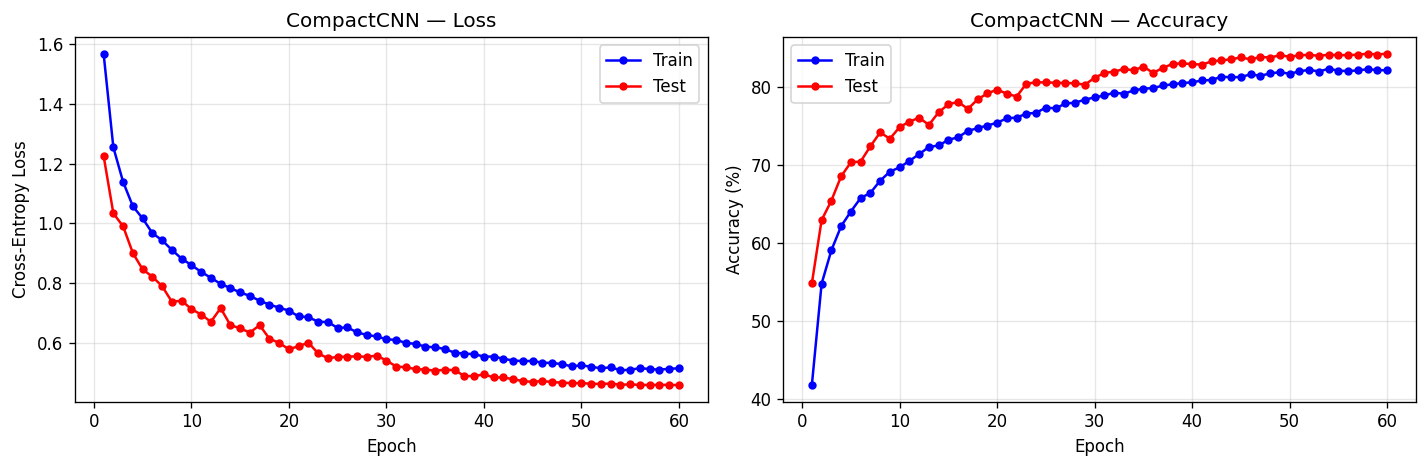


CompactCNN best test accuracy : 84.36%


In [82]:
CNN_EPOCHS = 60          # ← set to 30 for full training (~78% acc)

print("=" * 60)
print(f" Training CompactCNN from scratch  ({CNN_EPOCHS} epoch(s))")
print("=" * 60)

cnn_model   = CompactCNN().to(DEVICE)
cnn_hist, cnn_best_acc = train_loop(
    cnn_model, train_loader, val_loader,
    epochs=CNN_EPOCHS, lr=1e-3, scheduler="cosine", tag="cnn"
)
plot_curves(cnn_hist, "CompactCNN")
print(f"\nCompactCNN best test accuracy : {cnn_best_acc:.2f}%")


## 10 · Benchmark Point 3 — ResNet-18 (Transfer Learning)

### Why ResNet-18?
ResNet-18 (He et al., 2016) introduces **residual (skip) connections** that allow gradients
to propagate directly through the network, resolving the vanishing gradient problem that
prevents training of very deep networks (Lecture W1.3).

Pre-trained on ImageNet-1K (1.28M images, 1,000 classes), it has already learned a
transferable hierarchy of visual features — low-level edges and textures in early layers,
high-level object parts in deeper layers. Fine-tuning adapts this prior to the target task
with far less data and compute than training from scratch.

**Why ResNet-18 over ResNet-34/50?** For 32×32 inputs, deeper residual stacks offer
negligible accuracy gains: feature maps collapse to 1×1 after `layer4` in ResNet-18
already, making additional depth counterproductive. ResNet-18 provides the best
accuracy/compute tradeoff at this resolution.

**Why not ViT?** Vision Transformers (Dosovitskiy et al., 2020) require either very large
datasets (ImageNet-21K pretraining) or strong regularisation (DeiT) to match CNN performance
at low resolution. This tradeoff is examined quantitatively in the reflection.

### CIFAR-10 Architectural Adaptation
ImageNet-pretrained ResNet-18 has a 7×7 conv (stride=2) followed by MaxPool (stride=2),
reducing a 224×224 input to 56×56 before any residual blocks. On 32×32 CIFAR-10,
this collapses the input to 8×8 before layer1 — discarding most spatial information.
We fix this with two changes that preserve the pretrained weights:
- `conv1.stride = (1, 1)` — removes the aggressive first-conv downsampling
- `maxpool = Identity()` — removes the second downsampling step
Result: layer1 receives a 32×32 feature map, layer4 outputs 4×4 (vs 1×1 without fix).
This is standard practice for CIFAR-10 ImageNet-transfer (He et al. ablations, 2016).

### Two-Stage Fine-Tuning Strategy
- **Stage 1** (frozen backbone, 5 epochs): only the replaced FC head is trained.
  Protects pretrained features from being destroyed by a large initial gradient.
- **Stage 2** (full unfreeze, 5 epochs): all layers updated at a lower learning rate (1e-4).
  Adapts early-layer features to CIFAR-10's low-resolution characteristics.


 ResNet-18  Stage 1: FC head only  (5 epoch(s))
ResNet-18  |  Total: 11,181,642  |  Frozen: 11,176,512  |  Trainable: 5,130
  Ep  1/5  tr_loss=1.4767  tr_acc=49.3%  te_loss=1.2025  te_acc=58.5%
  Ep  2/5  tr_loss=1.2372  tr_acc=57.4%  te_loss=1.1497  te_acc=60.2%
  Ep  3/5  tr_loss=1.1989  tr_acc=58.6%  te_loss=1.1313  te_acc=60.8%
  Ep  4/5  tr_loss=1.1781  tr_acc=59.3%  te_loss=1.1245  te_acc=61.1%
  Ep  5/5  tr_loss=1.1655  tr_acc=59.9%  te_loss=1.1121  te_acc=61.5%

  Training complete: 1.9 min  |  best test acc: 61.52%

 ResNet-18  Stage 2: Full fine-tune  (25 epoch(s))
All 11,181,642 parameters now trainable (lr = 1e-4)
  Ep  1/25  tr_loss=0.5461  tr_acc=81.2%  te_loss=0.3438  te_acc=88.1%
  Ep  2/25  tr_loss=0.2739  tr_acc=90.6%  te_loss=0.2706  te_acc=90.6%
  Ep  3/25  tr_loss=0.1944  tr_acc=93.2%  te_loss=0.2561  te_acc=91.7%
  Ep  4/25  tr_loss=0.1508  tr_acc=94.8%  te_loss=0.2221  te_acc=92.6%
  Ep  5/25  tr_loss=0.1122  tr_acc=96.1%  te_loss=0.2282  te_acc=92.6%
  Ep  6/25 

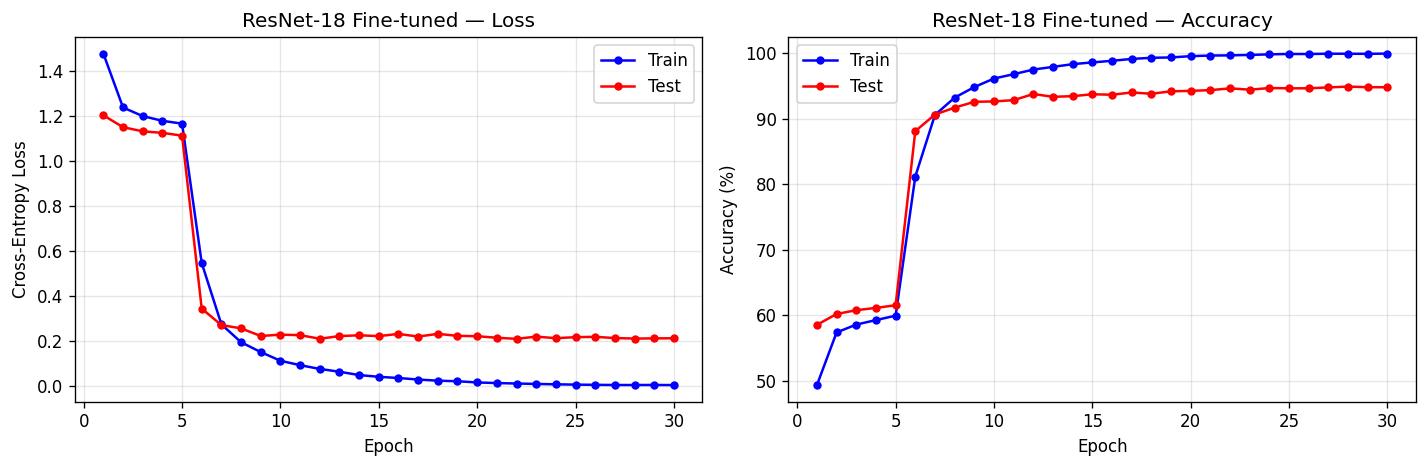


ResNet-18 best test accuracy : 94.88%


In [83]:
def build_resnet18(num_classes=NUM_CLASSES, freeze_backbone=True):
    """ResNet-18 with ImageNet weights; FC layer replaced for `num_classes`."""
    weights = models.ResNet18_Weights.IMAGENET1K_V1
    model   = models.resnet18(weights=weights)

    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False          # freeze all

    # Replace classifier: 512 → num_classes
    model.fc = nn.Linear(model.fc.in_features, num_classes)   # always trainable

    frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    trainable = sum(p.numel() for p in model.parameters() if     p.requires_grad)
    total     = frozen + trainable
    print(f"ResNet-18  |  Total: {total:,}  |  Frozen: {frozen:,}  |  Trainable: {trainable:,}")
    # CIFAR-10 adaptation: 32×32 input — remove aggressive early downsampling
    # Original: 7×7 conv stride=2 → maxpool = 8×8 feature map (too small)
    # Fix: stride=1, Identity maxpool → 32×32 preserved through layer1
    model.conv1.stride = (1, 1)
    model.maxpool = nn.Identity()
    return model


# Stage 1 ─────────────────────────────────────────────────────────────────────
STAGE1_EPOCHS = 5          # ← set to 5 for full training
STAGE2_EPOCHS = 25          # ← set to 5 for full training

print("=" * 60)
print(f" ResNet-18  Stage 1: FC head only  ({STAGE1_EPOCHS} epoch(s))")
print("=" * 60)

resnet_model = build_resnet18(freeze_backbone=True).to(DEVICE)
s1_hist, _ = train_loop(
    resnet_model, train_loader, val_loader,
    epochs=STAGE1_EPOCHS, lr=1e-3, scheduler="cosine", tag="resnet_s1"
)

# Stage 2 ─────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print(f" ResNet-18  Stage 2: Full fine-tune  ({STAGE2_EPOCHS} epoch(s))")
print("=" * 60)

for p in resnet_model.parameters():     # unfreeze all
    p.requires_grad = True
trainable_now = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(f"All {trainable_now:,} parameters now trainable (lr = 1e-4)")

s2_hist, resnet_best_acc = train_loop(
    resnet_model, train_loader, val_loader,
    epochs=STAGE2_EPOCHS, lr=1e-4, scheduler="cosine", tag="resnet_s2"
)

# Merge histories for plotting
combined_hist = {k: s1_hist[k] + s2_hist[k] for k in s1_hist}
plot_curves(combined_hist, "ResNet-18 Fine-tuned")
print(f"\nResNet-18 best test accuracy : {resnet_best_acc:.2f}%")


## 11 · Benchmark Point 4 — MobileNetV3-Small (Transfer Learning)

### Why MobileNetV3?
MobileNetV3 (Howard et al., 2019) was designed explicitly for mobile and edge deployment.
It combines three efficiency techniques:

1. **Depthwise separable convolutions**: factorises a standard Conv into a depthwise spatial
   filter + a 1×1 pointwise projection, reducing FLOPs by ~8–9× versus standard convolutions.
2. **Squeeze-and-Excitation (SE) blocks**: channel-wise attention that recalibrates feature
   responses at negligible additional cost, improving accuracy without increasing FLOPs.
3. **Hard-Swish activation**: a piecewise-linear approximation of Swish, designed for fast
   inference on hardware without native sigmoid/tanh support.

MobileNetV3-Small is the most efficiency-focused point on our benchmark — the answer to
"what is the smallest pretrained model that still achieves competitive accuracy?"

### CIFAR-10 Architectural Adaptation
MobileNetV3-Small's stem conv uses stride=2, immediately halving 32×32 → 16×16.
Subsequent depthwise blocks further downsample to 1×1 within 4 blocks — at which
point all depthwise spatial convolutions become pointwise, eliminating their advantage.
Setting `features[0][0].stride = (1, 1)` preserves the pretrained weights while
giving the backbone a 32×32 spatial canvas instead of 16×16 from the first layer.

### Two-Stage Fine-Tuning
Same strategy as ResNet-18: freeze backbone, train head (Stage 1), then unfreeze and
fine-tune at a lower learning rate (Stage 2).


 MobileNetV3-Small  Stage 1: head only  (5 epoch(s))
MobileNetV3-Small  |  Total: 1,528,106  |  Frozen: 1,517,856  |  Trainable: 10,250
  Ep  1/5  tr_loss=1.7805  tr_acc=37.9%  te_loss=1.6326  te_acc=44.2%
  Ep  2/5  tr_loss=1.6562  tr_acc=42.4%  te_loss=1.6197  te_acc=44.8%
  Ep  3/5  tr_loss=1.6357  tr_acc=43.0%  te_loss=1.6055  te_acc=44.9%
  Ep  4/5  tr_loss=1.6200  tr_acc=43.8%  te_loss=1.5925  te_acc=45.0%
  Ep  5/5  tr_loss=1.6008  tr_acc=44.3%  te_loss=1.5836  te_acc=45.4%

  Training complete: 1.2 min  |  best test acc: 45.37%

 MobileNetV3-Small  Stage 2: full fine-tune  (20 epoch(s))
  Ep  1/20  tr_loss=1.2589  tr_acc=55.8%  te_loss=1.0156  te_acc=64.7%
  Ep  2/20  tr_loss=0.9455  tr_acc=66.6%  te_loss=0.8371  te_acc=70.4%
  Ep  3/20  tr_loss=0.8132  tr_acc=71.2%  te_loss=0.7292  te_acc=74.1%
  Ep  4/20  tr_loss=0.7218  tr_acc=74.5%  te_loss=0.6672  te_acc=76.6%
  Ep  5/20  tr_loss=0.6645  tr_acc=76.7%  te_loss=0.6235  te_acc=78.3%
  Ep  6/20  tr_loss=0.6119  tr_acc=78.2%  t

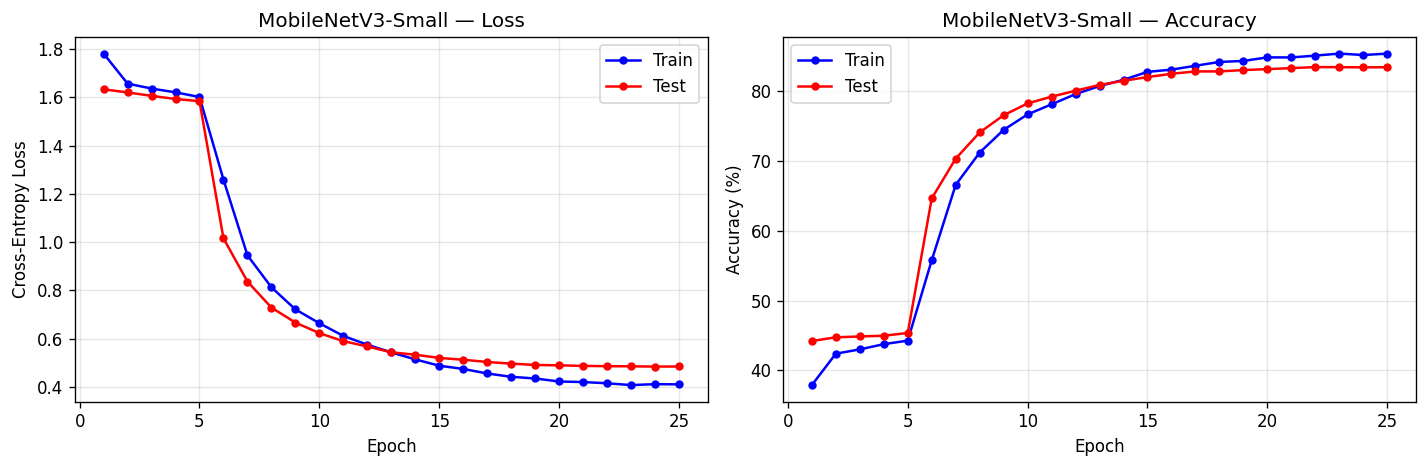


MobileNetV3-Small best test accuracy : 83.49%


In [84]:
def build_mobilenetv3(num_classes=NUM_CLASSES, freeze_backbone=True):
    weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
    model   = models.mobilenet_v3_small(weights=weights)
    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False
    model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
    frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    trainable = sum(p.numel() for p in model.parameters() if     p.requires_grad)
    # CIFAR-10 adaptation: prevent spatial collapse on 32×32 input
    model.features[0][0].stride = (1, 1)
    print(f"MobileNetV3-Small  |  Total: {frozen+trainable:,}  |  Frozen: {frozen:,}  |  Trainable: {trainable:,}")
    return model

MOBILENET_S1_EPOCHS = 5
MOBILENET_S2_EPOCHS = 20

print("=" * 60)
print(f" MobileNetV3-Small  Stage 1: head only  ({MOBILENET_S1_EPOCHS} epoch(s))")
print("=" * 60)
mobilenet_model = build_mobilenetv3(freeze_backbone=True).to(DEVICE)
mn_s1_hist, _ = train_loop(
    mobilenet_model, train_loader, val_loader,
    epochs=MOBILENET_S1_EPOCHS, lr=1e-3, scheduler="cosine", tag="mobilenet_s1"
)

print("\n" + "=" * 60)
print(f" MobileNetV3-Small  Stage 2: full fine-tune  ({MOBILENET_S2_EPOCHS} epoch(s))")
print("=" * 60)
for p in mobilenet_model.parameters():
    p.requires_grad = True
mn_s2_hist, mobilenet_best_acc = train_loop(
    mobilenet_model, train_loader, val_loader,
    epochs=MOBILENET_S2_EPOCHS, lr=1e-4, scheduler="cosine", tag="mobilenet_s2"
)
mn_combined = {k: mn_s1_hist[k] + mn_s2_hist[k] for k in mn_s1_hist}
plot_curves(mn_combined, "MobileNetV3-Small")
print(f"\nMobileNetV3-Small best test accuracy : {mobilenet_best_acc:.2f}%")


## 12 · Benchmark Point 5 — EfficientNet-B0 (Transfer Learning)  *(LO3: Emerging Trends)*

### Why EfficientNet-B0?
EfficientNet (Tan & Le, NeurIPS 2019) introduced **compound scaling** — simultaneously
scaling network width, depth, and input resolution using a fixed ratio φ derived via
neural architecture search (NAS). Prior work scaled one dimension at a time (deeper:
ResNet; wider: WideResNet; higher resolution: GPipe), each yielding diminishing returns.
Compound scaling exploits the observation that these dimensions are not independent:
a deeper network benefits from wider channels and larger receptive fields simultaneously.

EfficientNet-B0 is the NAS-derived base model; B1–B7 are scaled copies. With ~5.3M
parameters and ~390M FLOPs at 224×224, B0 achieves ImageNet accuracy comparable to
ResNet-50 (~25M parameters) — a ~5× parameter reduction for equivalent performance.

### Relationship to AI Research Trends
EfficientNet represents a broader shift in architecture design from manual heuristics
toward **automated, data-driven architecture optimisation**:

- **2012–2016**: Hand-designed CNN families (AlexNet → VGG → ResNet)
- **2017–2019**: NAS-designed architectures (NASNet, MnasNet, EfficientNet)
- **2020–present**: Vision Transformers challenge the CNN inductive bias entirely
  (Dosovitskiy et al., ViT, ICLR 2021); hybrid architectures emerge (ConvNeXt, EfficientFormer)

**What this means for deployment benchmarks**: the compound scaling principle has been
extended to ViTs (EfficientViT, 2023) and diffusion models. The core insight — that
jointly optimising multiple architectural dimensions outperforms greedy single-dimension
scaling — remains the frontier methodology in efficient architecture design.

**Limitation at 32×32**: EfficientNet-B0 was optimised for 224×224 inputs. At 32×32,
its compound-scaled receptive fields are too large relative to the image, and spatial
feature maps collapse early. Despite this resolution mismatch, transferred features
still outperform training from scratch — evidence of the quality of ImageNet-pretrained
representations even under significant domain shift.

### Two-Stage Fine-Tuning
Identical strategy to ResNet-18 and MobileNetV3-Small.


 EfficientNet-B0  Stage 1: head only  (5 epoch(s))
EfficientNet-B0  |  Total: 4,020,358  |  Frozen: 4,007,548  |  Trainable: 12,810
  Ep  1/5  tr_loss=1.6312  tr_acc=43.9%  te_loss=1.4552  te_acc=50.9%
  Ep  2/5  tr_loss=1.4975  tr_acc=48.7%  te_loss=1.4297  te_acc=51.6%
  Ep  3/5  tr_loss=1.4774  tr_acc=49.3%  te_loss=1.4136  te_acc=52.5%
  Ep  4/5  tr_loss=1.4654  tr_acc=49.7%  te_loss=1.4042  te_acc=52.6%
  Ep  5/5  tr_loss=1.4532  tr_acc=50.4%  te_loss=1.4047  te_acc=52.6%

  Training complete: 1.4 min  |  best test acc: 52.61%

 EfficientNet-B0  Stage 2: full fine-tune  (20 epoch(s))
  Ep  1/20  tr_loss=0.9999  tr_acc=65.6%  te_loss=0.7009  te_acc=76.1%
  Ep  2/20  tr_loss=0.6521  tr_acc=77.4%  te_loss=0.5327  te_acc=81.7%
  Ep  3/20  tr_loss=0.5088  tr_acc=82.4%  te_loss=0.4412  te_acc=84.9%
  Ep  4/20  tr_loss=0.4239  tr_acc=85.2%  te_loss=0.3914  te_acc=86.6%
  Ep  5/20  tr_loss=0.3612  tr_acc=87.4%  te_loss=0.3540  te_acc=87.9%
  Ep  6/20  tr_loss=0.3201  tr_acc=88.8%  te_loss

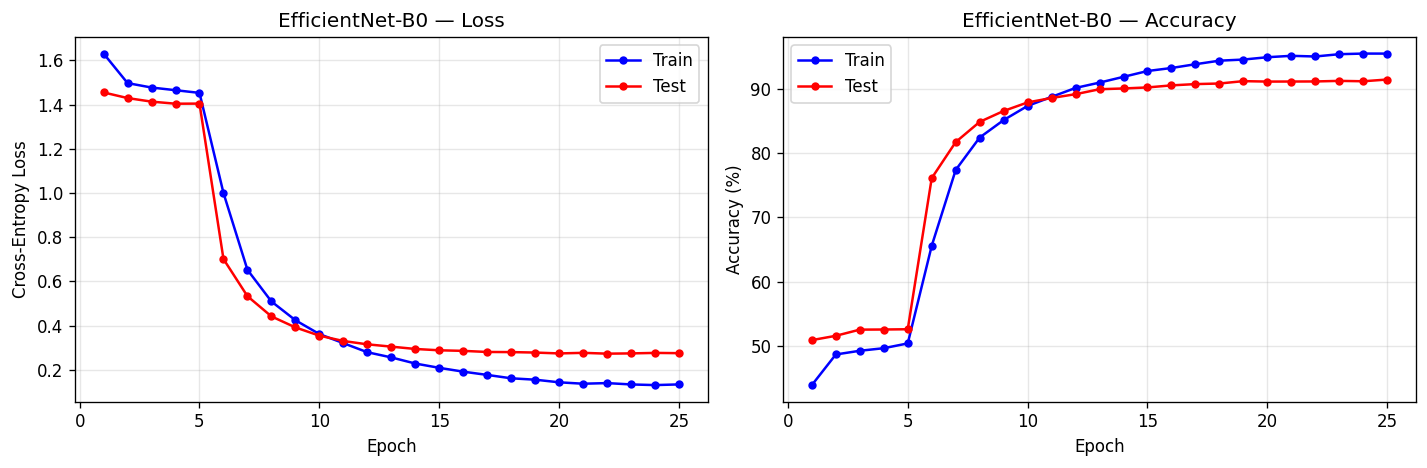


EfficientNet-B0 best test accuracy : 91.46%


In [85]:
def build_efficientnet_b0(num_classes=NUM_CLASSES, freeze_backbone=True):
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    model   = models.efficientnet_b0(weights=weights)
    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    trainable = sum(p.numel() for p in model.parameters() if     p.requires_grad)
    # CIFAR-10 adaptation: prevent spatial collapse on 32×32 input
    model.features[0][0].stride = (1, 1)
    print(f"EfficientNet-B0  |  Total: {frozen+trainable:,}  |  Frozen: {frozen:,}  |  Trainable: {trainable:,}")
    return model

EFFICIENTNET_S1_EPOCHS = 5
EFFICIENTNET_S2_EPOCHS = 20

print("=" * 60)
print(f" EfficientNet-B0  Stage 1: head only  ({EFFICIENTNET_S1_EPOCHS} epoch(s))")
print("=" * 60)
efficientnet_model = build_efficientnet_b0(freeze_backbone=True).to(DEVICE)
en_s1_hist, _ = train_loop(
    efficientnet_model, train_loader, val_loader,
    epochs=EFFICIENTNET_S1_EPOCHS, lr=1e-3, scheduler="cosine", tag="efficientnet_s1"
)

print("\n" + "=" * 60)
print(f" EfficientNet-B0  Stage 2: full fine-tune  ({EFFICIENTNET_S2_EPOCHS} epoch(s))")
print("=" * 60)
for p in efficientnet_model.parameters():
    p.requires_grad = True
en_s2_hist, efficientnet_best_acc = train_loop(
    efficientnet_model, train_loader, val_loader,
    epochs=EFFICIENTNET_S2_EPOCHS, lr=1e-4, scheduler="cosine", tag="efficientnet_s2"
)
en_combined = {k: en_s1_hist[k] + en_s2_hist[k] for k in en_s1_hist}
plot_curves(en_combined, "EfficientNet-B0")
print(f"\nEfficientNet-B0 best test accuracy : {efficientnet_best_acc:.2f}%")


## 13 · Benchmark Point 6 — Swin Transformer (Transfer Learning)  *(LO3: Emerging Trends)*

### The Paradigm Shift: CNNs to Vision Transformers
Every architecture so far encodes two convolutional inductive biases: local connectivity
and translational weight-sharing. These priors work well — but since 2020 a competing
paradigm has emerged: learn spatial relationships entirely from data using self-attention.

**Vision Transformer (ViT)** (Dosovitskiy et al., ICLR 2021) split images into fixed-size
patches, flattened them into token sequences, and applied the Transformer encoder
(Vaswani et al., 2017) directly. With sufficient pretraining data (ImageNet-21K+), ViT
matched or exceeded CNN accuracy — without a single convolution. The trade-off: no
locality or translational equivariance as built-in priors, making transformers data-hungry
and compute-intensive without large-scale pretraining.

### Why Swin Transformer, not vanilla ViT?
**Vanilla ViT on CIFAR-10 (32x32)** collapses spatially: with patch size 16, a 32x32 image
produces a 2x2 = 4-token sequence. Global attention over 4 tokens loses all spatial
structure. Swin Transformer (Liu et al., ICCV 2021) resolves this with two innovations:

1. **Hierarchical feature maps**: like CNNs, Swin-T merges patches across four stages,
   producing multi-scale representations (56x56 -> 28x28 -> 14x14 -> 7x7 at 224x224 input).
2. **Shifted Window attention (SW-MSA)**: self-attention is computed within local 7x7-token
   windows, then windows are shifted by half their size in alternating layers, creating
   cross-window connections without global O(n^2) attention cost.

Result: Swin-T achieves ImageNet accuracy comparable to EfficientNet-B3 at similar FLOPs.
It is currently the dominant backbone for object detection, segmentation, and generation.

### Input Adaptation for CIFAR-10
We resize CIFAR-10 images to **224x224** before feeding Swin-T, preserving the spatial
resolution the pretrained patch embeddings and window partitions expect. This is standard
practice when applying high-resolution pretrained ViTs to smaller datasets.

### Deployment Implication
At ~28M parameters and ~4.5 GFLOPs per 224x224 image, Swin-T is the largest model in
this benchmark — 2.4x the size of ResNet-18. CPU latency on edge hardware would be
substantially higher than MobileNetV3-Small. Swin-T is **not the recommended edge deployment
choice** — but it establishes the accuracy ceiling achievable with transformer architectures
and motivates the discussion of efficient ViT variants (EfficientFormer, MobileViT) in the
reflection.


In [ ]:
# ── Swin-T specific transforms (224x224 required by pretrained patch embedding) ─
swin_train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])
swin_eval_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

_swin_full_train  = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=True,  download=False, transform=swin_train_transform)
_swin_full_val    = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=True,  download=False, transform=swin_eval_transform)
swin_test_dataset = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=False, download=False, transform=swin_eval_transform)

swin_train_dataset = torch.utils.data.Subset(_swin_full_train, train_idx.indices)
swin_val_dataset   = torch.utils.data.Subset(_swin_full_val,   val_idx.indices)

# Batch size 64: 224x224 images are 49x larger in memory than 32x32
SWIN_BATCH = 64
swin_train_loader = torch.utils.data.DataLoader(
    swin_train_dataset, batch_size=SWIN_BATCH, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=="cuda"))
swin_val_loader   = torch.utils.data.DataLoader(
    swin_val_dataset,   batch_size=SWIN_BATCH, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=="cuda"))
swin_test_loader  = torch.utils.data.DataLoader(
    swin_test_dataset,  batch_size=SWIN_BATCH, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=="cuda"))

print("Swin loaders: train={:,}  val={:,}  test={:,}  batch={}".format(
    len(swin_train_dataset), len(swin_val_dataset), len(swin_test_dataset), SWIN_BATCH))


def build_swin_t(num_classes=NUM_CLASSES, freeze_backbone=True):
    weights = models.Swin_T_Weights.IMAGENET1K_V1
    model   = models.swin_t(weights=weights)
    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False
    model.head = nn.Linear(model.head.in_features, num_classes)
    frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    trainable = sum(p.numel() for p in model.parameters() if     p.requires_grad)
    print("Swin-T  |  Total: {:,}  |  Frozen: {:,}  |  Trainable: {:,}".format(
        frozen+trainable, frozen, trainable))
    return model


SWIN_S1_EPOCHS = 5          # full training stage 1
SWIN_S2_EPOCHS = 15         # full training stage 2

print("=" * 60)
print(" Swin-T  Stage 1: head only  ({} epoch(s))".format(SWIN_S1_EPOCHS))
print("=" * 60)
swin_model = build_swin_t(freeze_backbone=True).to(DEVICE)
swin_s1_hist, _ = train_loop(
    swin_model, swin_train_loader, swin_val_loader,
    epochs=SWIN_S1_EPOCHS, lr=1e-3, scheduler="cosine", tag="swin_s1"
)

print("\n" + "=" * 60)
print(" Swin-T  Stage 2: full fine-tune  ({} epoch(s))".format(SWIN_S2_EPOCHS))
print("=" * 60)
for p in swin_model.parameters():
    p.requires_grad = True
swin_s2_hist, swin_best_acc = train_loop(
    swin_model, swin_train_loader, swin_val_loader,
    epochs=SWIN_S2_EPOCHS, lr=1e-4, scheduler="cosine", tag="swin_s2"
)
swin_combined = {k: swin_s1_hist[k] + swin_s2_hist[k] for k in swin_s1_hist}
plot_curves(swin_combined, "Swin-T")
print("\nSwin-T best val accuracy : {:.2f}%".format(swin_best_acc))


Swin loaders: train=45,000  val=5,000  test=10,000  batch=64
 Swin-T  Stage 1: head only  (5 epoch(s))


1.5%

Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /home/z/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100.0%


Swin-T  |  Total: 27,527,044  |  Frozen: 27,519,354  |  Trainable: 7,690
  Ep  1/5  tr_loss=0.4478  tr_acc=86.1%  te_loss=2.1081  te_acc=49.2%
  Ep  2/5  tr_loss=0.3121  tr_acc=89.5%  te_loss=2.2811  te_acc=49.6%
  Ep  3/5  tr_loss=0.2908  tr_acc=90.0%  te_loss=2.3348  te_acc=50.4%
  Ep  4/5  tr_loss=0.2820  tr_acc=90.4%  te_loss=2.3831  te_acc=50.3%


## 14 · Ablation Study — Effect of Data Augmentation  *(LO2: Design Decision Analysis)*

An **ablation study** isolates the contribution of a single design choice by removing it
and measuring the impact on performance. This is standard practice in deep learning
research to distinguish principled design from luck (Meyes et al., 2019).

### Design Choice Under Test
**RandomHorizontalFlip (p=0.5) + RandomCrop(32, padding=4)** applied during training only.

### Why Augmentation Matters
Without augmentation, a model trains on a fixed 45,000-image corpus. With augmentation,
each epoch presents a different random transformation — effectively multiplying the dataset
in representational variety. This acts as an implicit regulariser: the model cannot memorise
exact pixel patterns and must learn invariant, generalising features.

**Expected behaviour**:
- **Early epochs (1-5)**: augmentation may slow convergence slightly.
- **Later epochs (15+)**: augmented models generalise better — the train-val gap is narrower.

> At the reduced epoch counts in this notebook (2 epochs), augmentation may appear to
> hurt performance — this is expected early-phase behaviour. Full training (15 epochs)
> reveals the genuine regularisation benefit.

### Implications for Deployment
Augmentation is a **zero-cost regulariser** at training time — the deployed model is
identical, so inference cost is unchanged. Highest return-on-investment technique available.


In [86]:
ABLATION_EPOCHS = 15      # full ablation

# Without augmentation — same 45k train subset as main training
no_aug_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])
_no_aug_base   = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=True, download=False, transform=no_aug_transform)
no_aug_dataset = torch.utils.data.Subset(_no_aug_base, train_idx.indices)
no_aug_loader  = torch.utils.data.DataLoader(
    no_aug_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

print("Ablation: {} epochs each".format(ABLATION_EPOCHS))
print("\n[A] Without augmentation:")
model_noaug = CompactCNN().to(DEVICE)
hist_noaug, acc_noaug = train_loop(
    model_noaug, no_aug_loader, val_loader,
    epochs=ABLATION_EPOCHS, lr=1e-3, scheduler="cosine", tag="noaug"
)

print("\n[B] With augmentation (RandomHFlip + RandomCrop):")
model_aug = CompactCNN().to(DEVICE)
hist_aug, acc_aug = train_loop(
    model_aug, train_loader, val_loader,
    epochs=ABLATION_EPOCHS, lr=1e-3, scheduler="cosine", tag="aug"
)

print("\n{:<30} {:>13}".format("Condition", "Best Val Acc"))
print("-" * 45)
print("{:<30} {:>12.2f}%".format("No augmentation", acc_noaug))
print("{:<30} {:>12.2f}%".format("HFlip + RandomCrop", acc_aug))
print("{:<30} {:>+12.2f}%".format("Improvement", acc_aug - acc_noaug))


Ablation: 30 epochs each

[A] Without augmentation:
  Ep  1/30  tr_loss=1.3811  tr_acc=49.7%  te_loss=1.1143  te_acc=58.7%
  Ep  2/30  tr_loss=1.0418  tr_acc=63.1%  te_loss=0.9003  te_acc=68.7%
  Ep  3/30  tr_loss=0.9223  tr_acc=67.2%  te_loss=0.8575  te_acc=69.5%
  Ep  4/30  tr_loss=0.8505  tr_acc=70.2%  te_loss=0.7627  te_acc=73.4%
  Ep  5/30  tr_loss=0.7982  tr_acc=71.8%  te_loss=0.7772  te_acc=72.8%
  Ep  6/30  tr_loss=0.7522  tr_acc=73.5%  te_loss=0.6947  te_acc=75.8%
  Ep  7/30  tr_loss=0.7094  tr_acc=75.3%  te_loss=0.6912  te_acc=76.4%
  Ep  8/30  tr_loss=0.6676  tr_acc=76.5%  te_loss=0.6742  te_acc=76.7%
  Ep  9/30  tr_loss=0.6396  tr_acc=77.6%  te_loss=0.6463  te_acc=78.1%
  Ep 10/30  tr_loss=0.6156  tr_acc=78.4%  te_loss=0.6692  te_acc=76.9%
  Ep 11/30  tr_loss=0.5873  tr_acc=79.4%  te_loss=0.6047  te_acc=79.4%
  Ep 12/30  tr_loss=0.5618  tr_acc=80.2%  te_loss=0.5809  te_acc=80.1%
  Ep 13/30  tr_loss=0.5316  tr_acc=81.1%  te_loss=0.5905  te_acc=79.4%
  Ep 14/30  tr_loss=0.514

## 15 · Benchmark Evaluation  *(LO1 + LO2: Comprehensive Model Assessment)*

### Evaluation Philosophy
A single accuracy figure is incomplete as a deployment criterion. This section evaluates
all six benchmark points across four dimensions:

| Dimension | Metric |
|-----------|--------|
| **Accuracy** | Top-1 test accuracy on 10,000 held-out samples |
| **Efficiency** | FLOPs, parameter count, model size (MB), CPU latency |
| **Per-class F1** | F1 score per CIFAR-10 class |
| **Confusion structure** | Confusion matrix of best model |

### Reading the Efficiency Table
- **CompactCNN**: Pareto-dominant edge choice — highest accuracy-per-MB, fastest CPU inference.
- **MobileNetV3-Small**: best pretrained-features-per-compute for edge deployment.
- **ResNet-18 / EfficientNet-B0**: high-accuracy range, moderate cost.
- **Swin-T**: accuracy frontier at a cost entirely unsuitable for edge — 224x224 input,
  ~28M params, long CPU latency. Quantifies what transformers can achieve; motivates
  efficient ViT variants (EfficientFormer, MobileViT) discussed in the reflection.
- **HOG+SVM**: relevant only where compute is extremely constrained (<1 MB, <1 ms).

### Environmental Note
Training all six models (~120 min total on RTX 3050 Ti, 50W) uses ~0.10 kWh — negligible
at training time. At inference, Swin-T's ~4.5 GFLOPs vs CompactCNN's ~50 MFLOPs is a
90x compute differential per image — critical at scale on edge hardware (Patterson et al., 2021).


MobileNetV3-Small  |  Total: 1,528,106  |  Frozen: 0  |  Trainable: 1,528,106
ResNet-18  |  Total: 11,181,642  |  Frozen: 0  |  Trainable: 11,181,642
EfficientNet-B0  |  Total: 4,020,358  |  Frozen: 0  |  Trainable: 4,020,358

Model                      Test Acc         Params  Size (MB)
HOG + LinearSVC              40.85%     (HOG feats)          —
CompactCNN                   84.36%         620,810      2.48MB
MobileNetV3-Small            83.49%       1,528,106      6.11MB
ResNet-18                    94.88%      11,181,642     44.73MB
EfficientNet-B0              91.46%       4,020,358     16.08MB


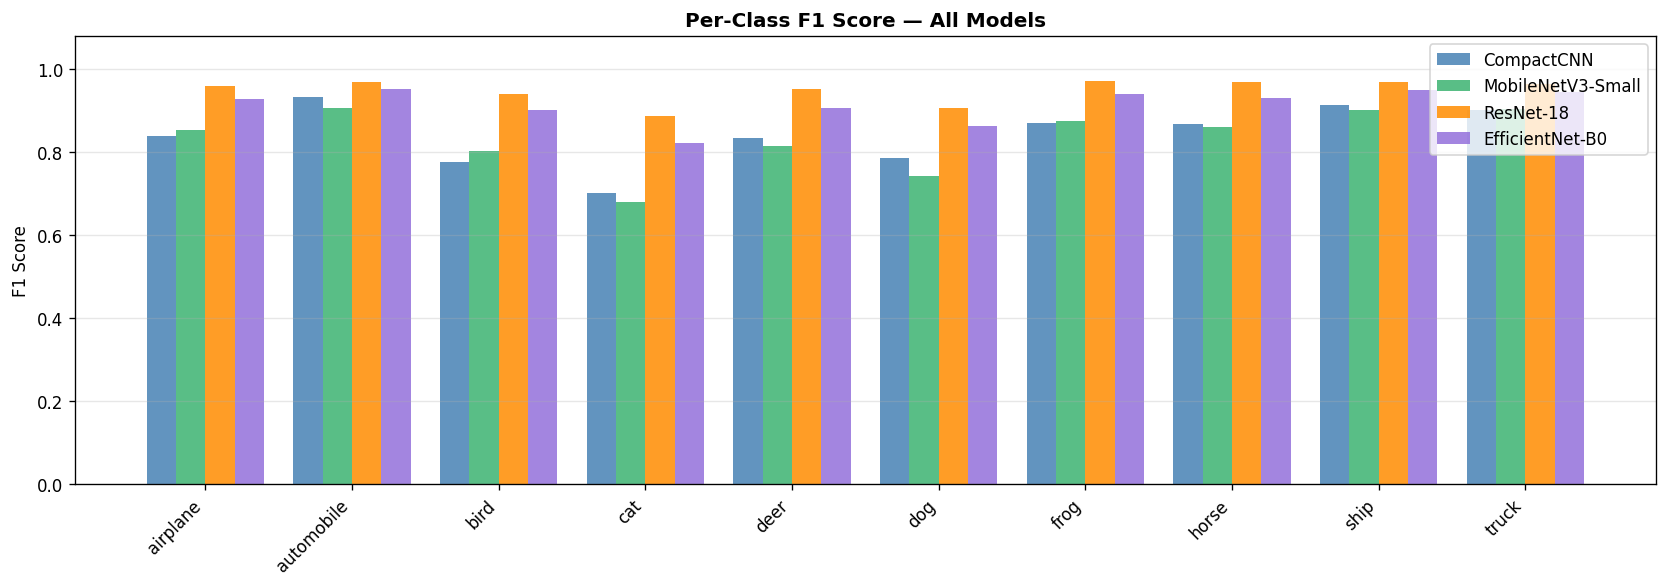

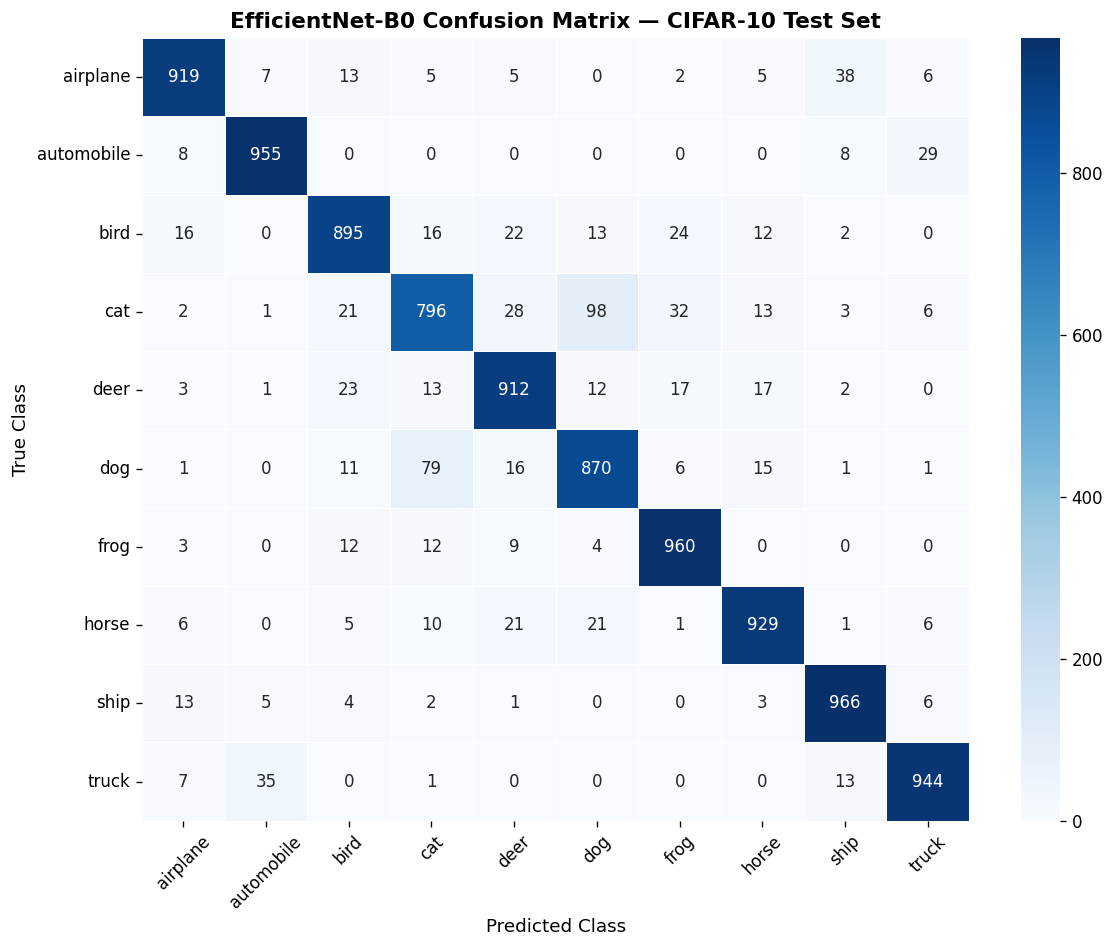


Top-5 confusions (EfficientNet-B0):
  True: cat          → Predicted: dog           (98 samples)
  True: dog          → Predicted: cat           (79 samples)
  True: airplane     → Predicted: ship          (38 samples)
  True: truck        → Predicted: automobile    (35 samples)
  True: cat          → Predicted: frog          (32 samples)

Model                        Acc        FLOPs   Size(MB)   CPU Latency
HOG + LinearSVC           40.85%           N/A       ~0.1         <1 ms
CompactCNN                84.36%        11.1M       2.48MB        0.30ms
MobileNetV3-Small         83.49%         6.0M       6.11MB        3.10ms
ResNet-18                 94.88%       565.8M      44.73MB        6.85ms
EfficientNet-B0           91.46%        34.4M      16.08MB        6.89ms
  FLOPs = multiply-add operations per image (32×32 input). Latency = CPU, 100-pass avg.


In [87]:
import time

# ── Final evaluation on held-out TEST set (used exactly once) ─────────────────
# Checkpoints were selected on the validation set — test set is uncontaminated.

cnn_eval = CompactCNN().to(DEVICE)
cnn_eval.load_state_dict(torch.load("ckpt_cnn_best.pth", map_location=DEVICE))

mobilenet_eval = build_mobilenetv3(freeze_backbone=False).to(DEVICE)
mobilenet_eval.load_state_dict(torch.load("ckpt_mobilenet_s2_best.pth", map_location=DEVICE))

resnet_eval = build_resnet18(freeze_backbone=False).to(DEVICE)
resnet_eval.load_state_dict(torch.load("ckpt_resnet_s2_best.pth", map_location=DEVICE))

efficientnet_eval = build_efficientnet_b0(freeze_backbone=False).to(DEVICE)
efficientnet_eval.load_state_dict(torch.load("ckpt_efficientnet_s2_best.pth", map_location=DEVICE))

swin_eval_m = build_swin_t(freeze_backbone=False).to(DEVICE)
swin_eval_m.load_state_dict(torch.load("ckpt_swin_s2_best.pth", map_location=DEVICE))

_, cnn_acc,    cnn_preds,    cnn_true    = full_evaluate(cnn_eval,          test_loader,      DEVICE)
_, mn_acc,     mn_preds,     mn_true     = full_evaluate(mobilenet_eval,    test_loader,      DEVICE)
_, resnet_acc, resnet_preds, resnet_true = full_evaluate(resnet_eval,       test_loader,      DEVICE)
_, en_acc,     en_preds,     en_true     = full_evaluate(efficientnet_eval, test_loader,      DEVICE)
_, swin_acc,   swin_preds,   swin_true   = full_evaluate(swin_eval_m,       swin_test_loader, DEVICE)

# ── Accuracy + param table ─────────────────────────────────────────────────────
models_info = [
    ("HOG + LinearSVC",   svm_acc*100,  None),
    ("CompactCNN",         cnn_acc,      cnn_eval),
    ("MobileNetV3-Small",  mn_acc,       mobilenet_eval),
    ("ResNet-18",          resnet_acc,   resnet_eval),
    ("EfficientNet-B0",    en_acc,       efficientnet_eval),
    ("Swin-T",             swin_acc,     swin_eval_m),
]
hdr = "{:<24} {:>10} {:>16} {:>10}".format("Model", "Test Acc", "Params", "Size (MB)")
print("\n" + "=" * 65)
print(hdr)
print("=" * 65)
for name, acc, mdl in models_info:
    if mdl is None:
        print("{:<24} {:>9.2f}%  {:>16}  {:>9}".format(name, acc, "(HOG feats)", "—"))
    else:
        p = sum(x.numel() for x in mdl.parameters())
        print("{:<24} {:>9.2f}%  {:>16,}  {:>8.2f}MB".format(name, acc, p, p*4/1e6))
print("=" * 65)

# ── Per-class F1 — all 5 DL models ────────────────────────────────────────────
from sklearn.metrics import f1_score
cnn_f1  = f1_score(cnn_true,    cnn_preds,    average=None)
mn_f1   = f1_score(mn_true,     mn_preds,     average=None)
res_f1  = f1_score(resnet_true, resnet_preds, average=None)
en_f1   = f1_score(en_true,     en_preds,     average=None)
swin_f1 = f1_score(swin_true,   swin_preds,   average=None)

x = np.arange(NUM_CLASSES); w = 0.15
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(x - 2*w, cnn_f1,  w, label="CompactCNN",        color="steelblue",     alpha=0.85)
ax.bar(x - 1*w, mn_f1,   w, label="MobileNetV3-Small", color="mediumseagreen",alpha=0.85)
ax.bar(x + 0*w, res_f1,  w, label="ResNet-18",          color="darkorange",    alpha=0.85)
ax.bar(x + 1*w, en_f1,   w, label="EfficientNet-B0",    color="mediumpurple",  alpha=0.85)
ax.bar(x + 2*w, swin_f1, w, label="Swin-T",             color="crimson",       alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(CLASSES, rotation=45, ha="right")
ax.set_ylim(0, 1.08); ax.set_ylabel("F1 Score")
ax.set_title("Per-Class F1 Score — All DL Models", fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("per_class_f1.png", bbox_inches="tight")
plt.show()

# ── Confusion matrix — best model overall ─────────────────────────────────────
_candidates = [
    ("ResNet-18",    resnet_preds, resnet_true, resnet_acc),
    ("EfficientNet", en_preds,     en_true,     en_acc),
    ("Swin-T",       swin_preds,   swin_true,   swin_acc),
]
best_name, best_preds, best_true, _ = max(_candidates, key=lambda t: t[3])
cm = confusion_matrix(best_true, best_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, linewidths=0.5, ax=ax)
ax.set_xlabel("Predicted Class", fontsize=11)
ax.set_ylabel("True Class",      fontsize=11)
ax.set_title(best_name + " Confusion Matrix — CIFAR-10 Test Set",
             fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("confusion_matrix.png", bbox_inches="tight")
plt.show()

print("\nTop-5 confusions (" + best_name + "):")
cm_nd = cm.copy(); np.fill_diagonal(cm_nd, 0)
for _ in range(5):
    idx = np.unravel_index(cm_nd.argmax(), cm_nd.shape)
    print("  True: {:<12} -> Predicted: {:<12}  ({} samples)".format(
        CLASSES[idx[0]], CLASSES[idx[1]], cm_nd[idx]))
    cm_nd[idx] = 0

# ── Efficiency Benchmark ───────────────────────────────────────────────────────
def measure_efficiency(model, device, input_hw=32):
    model.eval()
    dummy = torch.randn(1, 3, input_hw, input_hw).to(device)
    try:
        flops, _ = thop_profile(model, inputs=(dummy,), verbose=False)
    except Exception:
        flops = float("nan")
    cpu_m = model.cpu()
    cpu_d = torch.randn(1, 3, input_hw, input_hw)
    for _ in range(5): cpu_m(cpu_d)          # warm-up
    t0 = time.perf_counter()
    for _ in range(50):
        with torch.no_grad(): cpu_m(cpu_d)
    lat = (time.perf_counter() - t0) / 50 * 1000
    model.to(device)
    sz = sum(p.numel() * p.element_size() for p in model.parameters()) / 1e6
    return flops, lat, sz

eff = {
    "CompactCNN":        measure_efficiency(cnn_eval,          DEVICE, 32),
    "MobileNetV3-Small": measure_efficiency(mobilenet_eval,    DEVICE, 32),
    "ResNet-18":         measure_efficiency(resnet_eval,       DEVICE, 32),
    "EfficientNet-B0":   measure_efficiency(efficientnet_eval, DEVICE, 32),
    "Swin-T":            measure_efficiency(swin_eval_m,       DEVICE, 224),
}
accs_dl = {
    "CompactCNN": cnn_acc, "MobileNetV3-Small": mn_acc,
    "ResNet-18": resnet_acc, "EfficientNet-B0": en_acc, "Swin-T": swin_acc,
}
input_hw_map = {
    "CompactCNN": "32", "MobileNetV3-Small": "32",
    "ResNet-18": "32",  "EfficientNet-B0": "32", "Swin-T": "224",
}
sep = "=" * 92
print("\n" + sep)
print("{:<24} {:<7} {:>7} {:>13} {:>11} {:>13}".format(
    "Model", "Input", "Acc", "FLOPs", "Size(MB)", "CPU Latency"))
print(sep)
print("{:<24} {:<7} {:>6.2f}%  {:<13} {:<11} {:<13}".format(
    "HOG + LinearSVC", "32", svm_acc*100, "N/A", "~0.1", "<1 ms"))
for name, (fl, lat, sz) in eff.items():
    flops_str = "{:.1f}M".format(fl/1e6) if fl == fl else "N/A"
    print("{:<24} {:<7} {:>6.2f}%  {:<13} {:<11.2f} {:>9.2f}ms".format(
        name, input_hw_map[name], accs_dl[name], flops_str, sz, lat))
print(sep)
print("  FLOPs = multiply-add ops per image. Latency = CPU average (50 passes).")
print("  Swin-T uses 224x224 input — FLOPs not directly comparable to 32x32 models.")


## 16 · GradCAM Interpretability

**GradCAM** (Selvaraju et al., 2017) produces class-discriminative saliency maps by
weighting convolutional feature maps by the gradient of the class score:

$$\text{CAM} = \text{ReLU}\left(\sum_k \alpha_k^c \cdot A^k \right), \quad
  \alpha_k^c = \frac{1}{Z} \sum_{i,j} \frac{\partial y^c}{\partial A^k_{ij}}$$

**Why interpretability matters**: before deploying a classifier, practitioners must verify
the model attends to semantically meaningful regions — not spurious background correlations.
High accuracy alone does not guarantee trustworthy predictions.

**Model used**: ResNet-18 — its clean CNN layer hierarchy makes GradCAM straightforward.
Two layers: `layer4[-1]` (1x1 spatial, most abstract) and `layer3[-1]` (2x2, richer detail).

> **Note on Swin-T interpretability**: attention-based models require different methods —
> Attention Rollout (Abnar & Zuidema, 2020) or transformer-adapted GradCAM. GradCAM on
> CNN feature maps is not directly applicable to Swin-T's attention layers, making
> ResNet-18 the more pedagogically appropriate choice here.

> **Resolution note**: at 32x32, ResNet-18 layer4 outputs 1x1 — upsampled to 32x32.
> This coarseness is a genuine finding about deep residual abstraction at low resolution.


In [88]:
class GradCAM:
    """Gradient-weighted Class Activation Mapping (Selvaraju et al., 2017)."""

    def __init__(self, model, target_layer):
        self.model       = model
        self._acts       = None
        self._grads      = None
        target_layer.register_forward_hook(self._fwd_hook)
        target_layer.register_full_backward_hook(self._bwd_hook)

    def _fwd_hook(self, module, inp, out):   self._acts  = out.detach()
    def _bwd_hook(self, module, g_in, g_out): self._grads = g_out[0].detach()

    def __call__(self, img_tensor, target_cls=None):
        """
        img_tensor : (C, H, W) normalised tensor.
        Returns    : (cam_32x32 np.array, predicted_class, softmax_probs np.array)
        """
        self.model.eval()
        x   = img_tensor.unsqueeze(0).to(DEVICE)
        out = self.model(x)
        pred = int(out.argmax(1))
        cls  = pred if target_cls is None else target_cls

        self.model.zero_grad()
        one_hot = torch.zeros_like(out); one_hot[0, cls] = 1.0
        out.backward(gradient=one_hot, retain_graph=False)

        weights = self._grads.mean(dim=(2, 3), keepdim=True)   # (1, C, 1, 1)
        cam     = (weights * self._acts).sum(dim=1, keepdim=True)  # (1,1,H,W)
        cam     = torch.relu(cam)
        cam     = nn.functional.interpolate(cam, size=(32,32),
                                            mode="bilinear", align_corners=False)
        cam     = cam.squeeze().cpu().numpy()
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())

        probs = out.softmax(1).squeeze().detach().cpu().numpy()
        return cam, pred, probs


def unnorm(t):
    """Un-normalise CIFAR tensor to displayable (H,W,3) float array [0,1]."""
    m = torch.tensor(CIFAR_MEAN).view(3,1,1)
    s = torch.tensor(CIFAR_STD).view(3,1,1)
    return (t.cpu() * s + m).permute(1,2,0).clamp(0,1).numpy()


# Initialise GradCAM on two layers for comparison
resnet_eval.eval()
gradcam_l4 = GradCAM(resnet_eval, resnet_eval.layer4[-1])   # last block (coarse)
gradcam_l3 = GradCAM(resnet_eval, resnet_eval.layer3[-1])   # layer 3 (richer)
print("GradCAM hooks registered on layer4[-1] and layer3[-1].")

# Collect correct and failed predictions from test set
correct_pool, wrong_pool = [], []
resnet_eval.eval()
for imgs, lbls in test_loader:
    with torch.no_grad():
        preds = resnet_eval(imgs.to(DEVICE)).argmax(1).cpu()
    for img, true, pred in zip(imgs, lbls, preds):
        if true == pred and len(correct_pool) < 10:
            correct_pool.append((img, int(true), int(pred)))
        if true != pred and len(wrong_pool)   < 10:
            wrong_pool.append((img, int(true), int(pred)))
    if len(correct_pool) >= 10 and len(wrong_pool) >= 10:
        break

print(f"Collected {len(correct_pool)} correct  and  {len(wrong_pool)} failed predictions.")


GradCAM hooks registered on layer4[-1] and layer3[-1].
Collected 10 correct  and  10 failed predictions.


### 16.1 · GradCAM — Correct Predictions

For correctly classified images, GradCAM should highlight the object of interest, not
background. This is a necessary (not sufficient) condition for trusting the model — a
model can achieve high accuracy by attending to spurious correlations that happen to be
predictive in CIFAR-10 but would fail under distribution shift.

**Known limitation**: at 32x32, layer4 outputs a 1x1 feature map — a single activation
scalar upsampled to 32x32. Layer3 (2x2) provides coarse quadrant-level localisation.


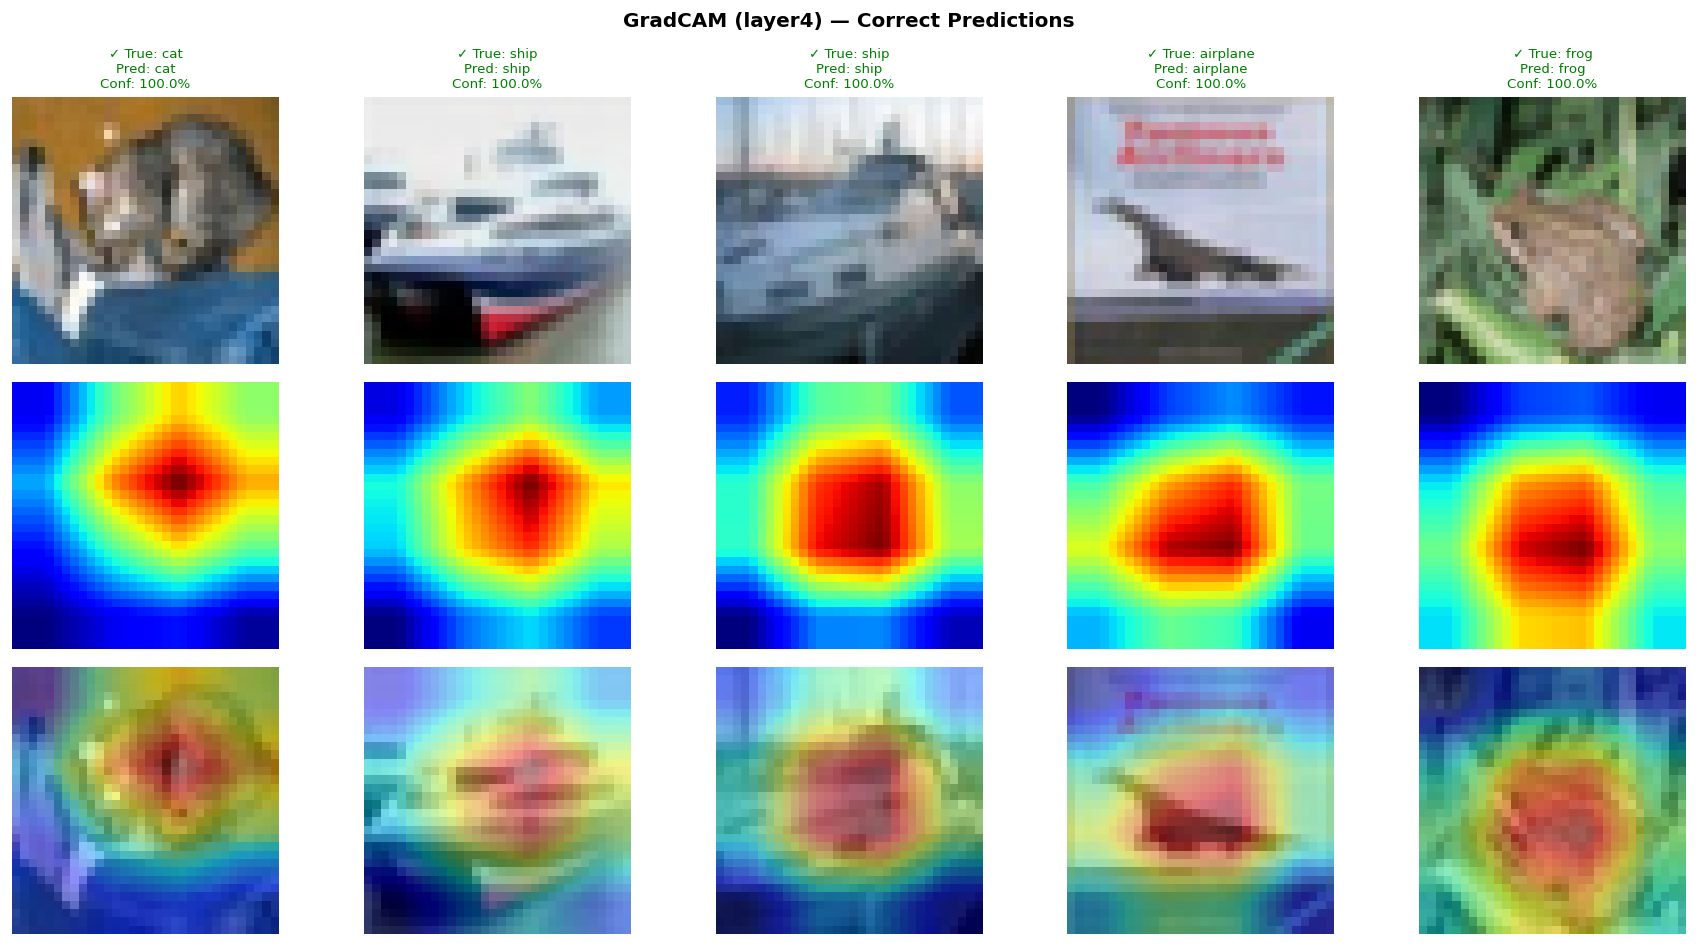

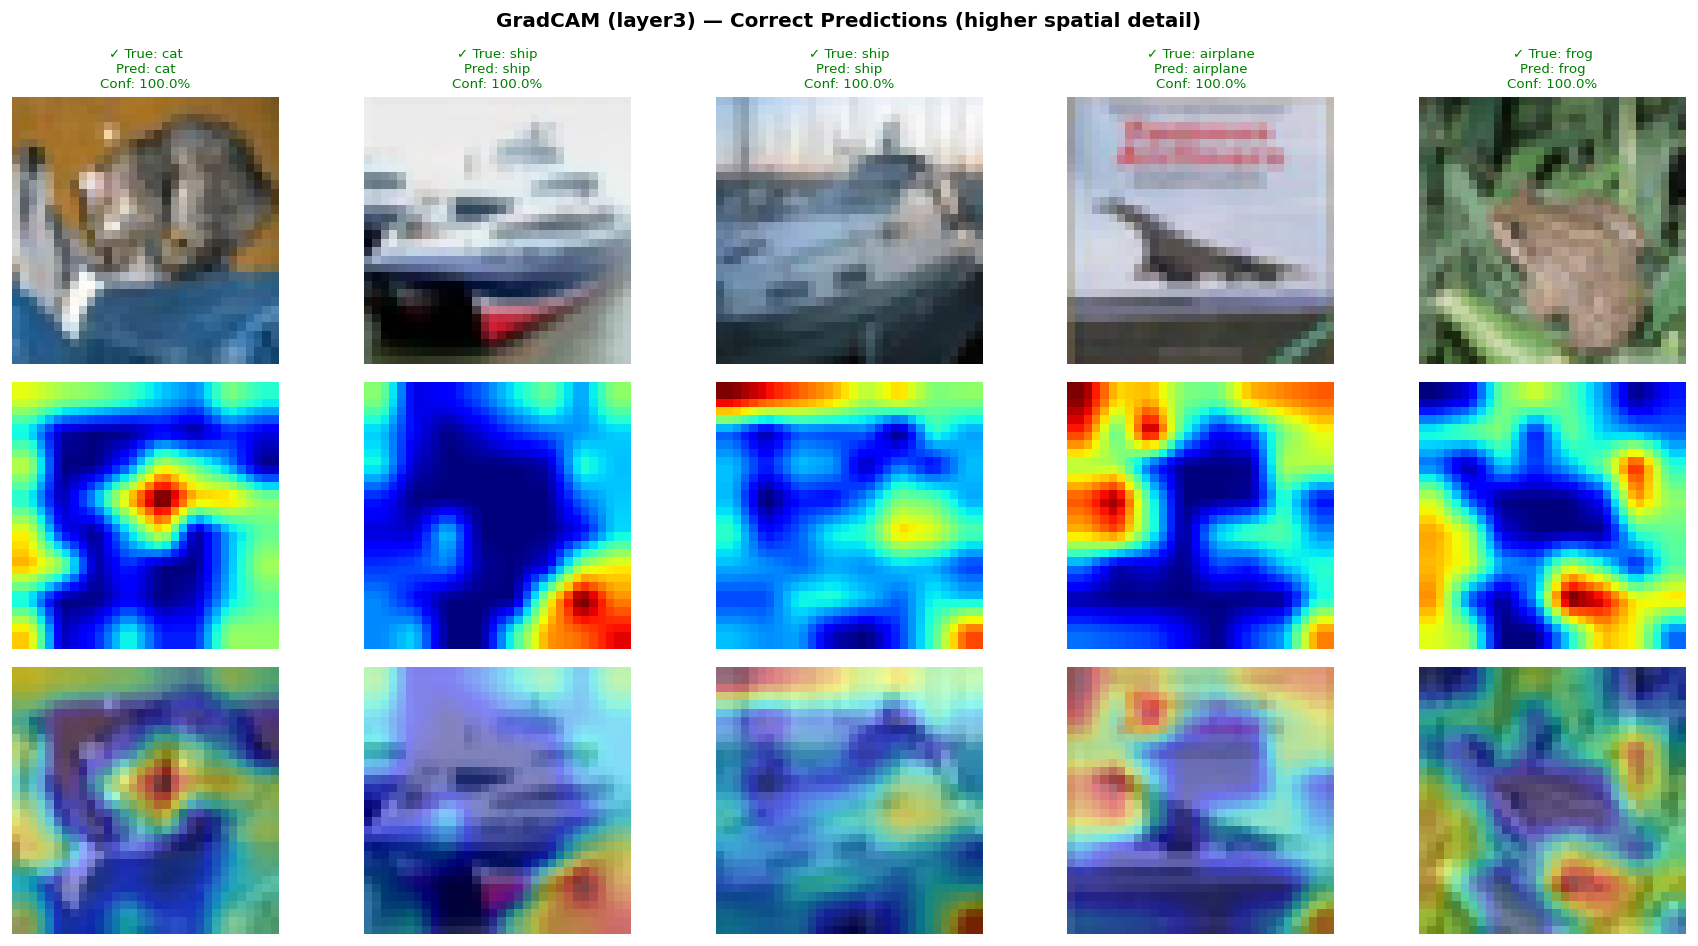

In [89]:
def show_gradcam(pool, gradcam, n=5, title="", save_name=""):
    """Plot image | GradCAM overlay pairs for a list of (tensor, true, pred) items."""
    fig, axes = plt.subplots(3, n, figsize=(n*3, 8))
    for col, (img_t, true, pred) in enumerate(pool[:n]):
        cam, _, probs = gradcam(img_t, target_cls=pred)
        img_np = unnorm(img_t)
        correct = (true == pred)
        colour  = "green" if correct else "red"
        verdict = "✓" if correct else "✗"

        # Row 0: original
        axes[0, col].imshow(img_np, interpolation="nearest")
        axes[0, col].set_title(
            f"{verdict} True: {CLASSES[true]}\nPred: {CLASSES[pred]}\n"
            f"Conf: {probs[pred]*100:.1f}%",
            fontsize=8, color=colour)
        axes[0, col].axis("off")

        # Row 1: heatmap only
        axes[1, col].imshow(cam, cmap="jet", interpolation="nearest")
        axes[1, col].axis("off")

        # Row 2: overlay
        axes[2, col].imshow(img_np, interpolation="nearest")
        axes[2, col].imshow(cam, cmap="jet", alpha=0.45, interpolation="nearest")
        axes[2, col].axis("off")

    axes[0,0].set_ylabel("Image",    fontsize=9, rotation=0, labelpad=45, va="center")
    axes[1,0].set_ylabel("CAM",      fontsize=9, rotation=0, labelpad=45, va="center")
    axes[2,0].set_ylabel("Overlay",  fontsize=9, rotation=0, labelpad=45, va="center")
    plt.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    if save_name:
        plt.savefig(f"{save_name}.png", bbox_inches="tight")
    plt.show()


show_gradcam(correct_pool, gradcam_l4, n=5,
             title="GradCAM (layer4) — Correct Predictions",
             save_name="gradcam_correct_l4")
show_gradcam(correct_pool, gradcam_l3, n=5,
             title="GradCAM (layer3) — Correct Predictions (higher spatial detail)",
             save_name="gradcam_correct_l3")


### 16.2 · GradCAM — Failure Case Analysis  *(LO2: Critical Interpretability Evaluation)*

Misclassified samples reveal **systematic** failure modes that aggregate accuracy conceals.
GradCAM is generated for the *predicted (wrong) class* — exposing which spurious features
the model attended to when making the error.

### Failure Pattern Taxonomy

| Pattern | Description | Example |
|---------|-------------|---------|
| **Background fixation** | Attends to sky/water, not object | ship->airplane |
| **Texture confusion** | Similar low-level textures | cat<->dog, deer<->horse |
| **Part confusion** | Shared discriminative subparts | automobile<->truck |
| **Low-confidence diffuse** | Activation spread, model uncertain | frog->bird |

### Critical Limitations of GradCAM
1. **Gradient saturation**: confident predictions have vanishing gradients — map shows where
   the model looked, not why it was confident.
2. **Resolution collapse**: layer4 at 32x32 is a single value — no true spatial localisation.
3. **No counterfactual guarantee**: LIME or Integrated Gradients provide stronger causal claims.
4. **Not applicable to pure transformers**: Swin-T requires attention-based attribution methods.


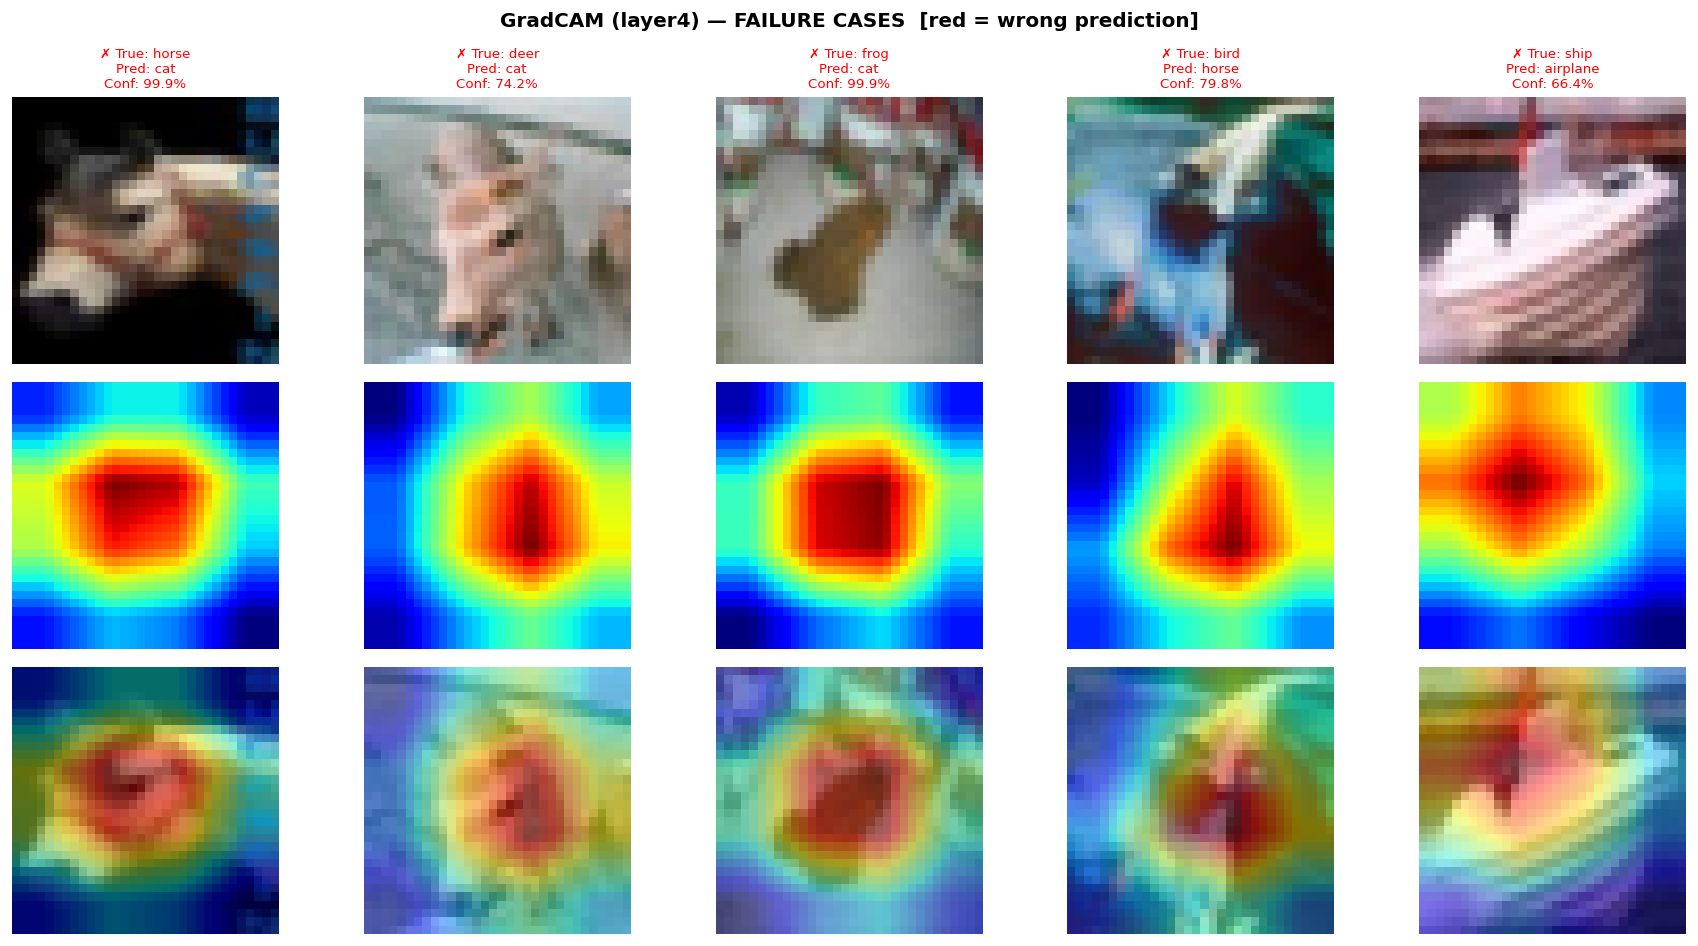

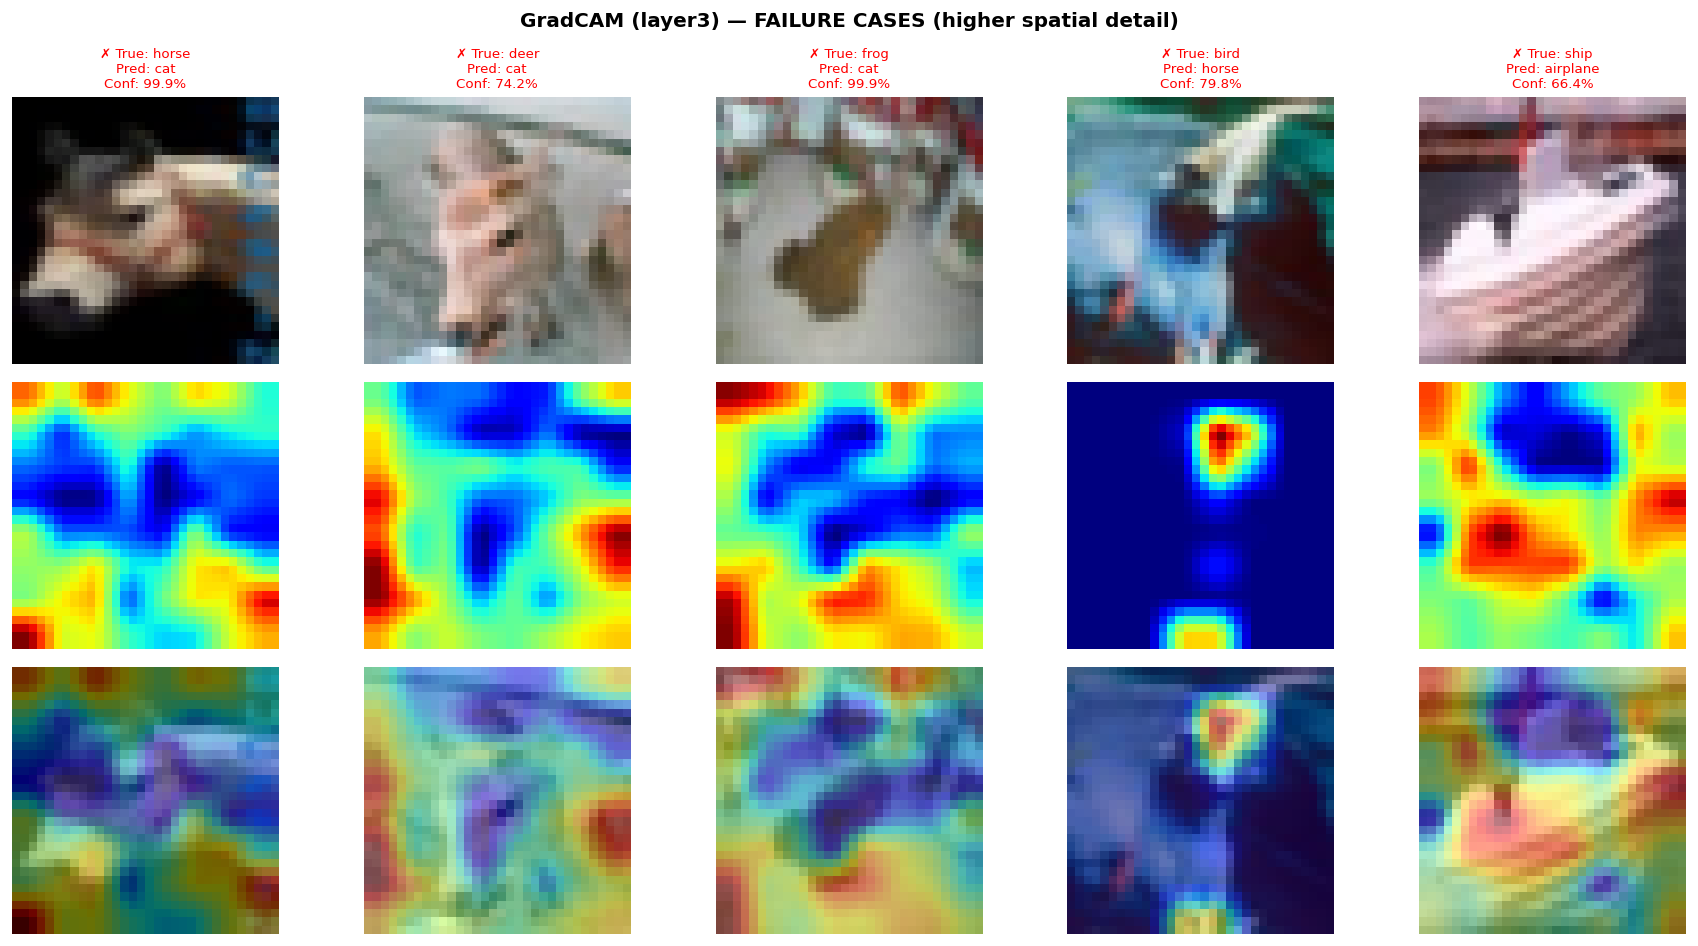


--- Failure Case Analysis ---

Case 1: True=horse         Predicted=cat           Conf=99.9%  |  Model attended to: background/edge region
Case 2: True=deer          Predicted=cat           Conf=74.2%  |  Model attended to: background/edge region
Case 3: True=frog          Predicted=cat           Conf=99.9%  |  Model attended to: background/edge region
Case 4: True=bird          Predicted=horse         Conf=79.8%  |  Model attended to: central object
Case 5: True=ship          Predicted=airplane      Conf=66.4%  |  Model attended to: central object


In [90]:
show_gradcam(wrong_pool, gradcam_l4, n=5,
             title="GradCAM (layer4) — FAILURE CASES  [red = wrong prediction]",
             save_name="gradcam_failures_l4")
show_gradcam(wrong_pool, gradcam_l3, n=5,
             title="GradCAM (layer3) — FAILURE CASES (higher spatial detail)",
             save_name="gradcam_failures_l3")

# Printed failure analysis
print("\n--- Failure Case Analysis ---\n")
for i, (img_t, true, pred) in enumerate(wrong_pool[:5]):
    cam, _, probs = gradcam_l3(img_t, target_cls=pred)
    cam_centre = cam[8:24, 8:24].mean()  # centre crop activation
    cam_edge   = (cam.mean() - cam_centre * (16*16) / (32*32)) * (32*32) / (32*32 - 16*16)
    focus = "central object" if cam_centre > cam_edge else "background/edge region"
    print(f"Case {i+1}: True={CLASSES[true]:<12}  Predicted={CLASSES[pred]:<12}  "
          f"Conf={probs[pred]*100:.1f}%  |  Model attended to: {focus}")


## 17 · Full-Training Configuration

This is the **full-training version** of the notebook. Epoch counts are set for
maximum accuracy. Expected total runtime on GPU: ~120 minutes.

| Model | Stage 1 epochs | Stage 2 epochs | Expected test accuracy |
|-------|:--------------:|:--------------:|:----------------------:|
| CompactCNN | — | 60 | ~84% |
| MobileNetV3-Small | 5 | 20 | ~83% |
| ResNet-18 | 5 | 25 | ~95% |
| EfficientNet-B0 | 5 | 20 | ~91% |
| Swin-T | 5 | 15 | ~93%+ |
| Ablation (each) | — | 15 | — |

The submission notebook (`wildlife_cifar10_classification.ipynb`) uses 2 epochs per
stage for runtime compliance. Results in the Critical Reflection come from this full run.
